In [11]:
# ==============================
# ЯЧЕЙКА 1: ИМПОРТ БИБЛИОТЕК И НАСТРОЙКА
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# PyTorch импорты
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F

# Scikit-learn импорты
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                           recall_score, roc_auc_score, confusion_matrix,roc_curve, auc)

# Проверка доступности CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA доступно: {torch.cuda.is_available()}")
    print(f"Количество GPU: {torch.cuda.device_count()}")

# Настройки отображения
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
%matplotlib inline

print("Библиотеки успешно импортированы!")

Используемое устройство: cpu
Библиотеки успешно импортированы!


In [2]:
# ==============================
# ЯЧЕЙКА 2: КОНФИГУРАЦИЯ И ФИЗИЧЕСКАЯ МОДЕЛЬ
# ==============================

BOILER_PARAMS = {
    'type': 'БКЗ-500-140атм',
    'nominal_pressure': 140,
    'nominal_temperature': 545,
    'max_temperature': 570,
    'min_temperature': 0,
    'work_threshold': 300,
    'resample_freq': '10T'
}

SENSORS = {
    '10HAH01CT103': {'surface_type': 'средние ширмы', 'stage': 2, 'stream': 1},
    '10HAH01CT102': {'surface_type': 'средние ширмы', 'stage': 2, 'stream': 1},
    '10HAH12CT101': {'surface_type': 'ширмы', 'stage': 2, 'stream': 1},
    '10HAH12CT104': {'surface_type': 'ширмы', 'stage': 2, 'stream': 4},
    '10HAH12CT110': {'surface_type': 'пароперегреватель', 'stage': 3, 'stream': 2},
    '10HAH12CT108': {'surface_type': 'пароперегреватель', 'stage': 3, 'stream': 2},
    '10HAH12CT106': {'surface_type': 'пароперегреватель', 'stage': 3, 'stream': 2},
    '10HAH11CT114': {'surface_type': 'пароперегреватель', 'stage': 4, 'stream': 1},
    '10HAH11CT113': {'surface_type': 'пароперегреватель', 'stage': 4, 'stream': 1},
    '10HAH12CT116': {'surface_type': 'ширмы', 'stage': 4, 'stream': 2},
    '10HAH12CT117': {'surface_type': 'ширмы', 'stage': 4, 'stream': 2}
}

class PerSensorPhysicsModel:
    """Физическая модель деградации для каждого датчика отдельно"""
    
    def __init__(self):
        self.boiler_params = BOILER_PARAMS
        self.sensor_geometry = self._init_sensor_geometry()
        
    def _init_sensor_geometry(self):
        return {
            'средние ширмы': {'thickness': 0.004, 'area': 120, 'k': 850},
            'ширмы': {'thickness': 0.0045, 'area': 95, 'k': 900},
            'пароперегреватель': {'thickness': 0.005, 'area': 85, 'k': 950}
        }
    
    def calculate_allowable_stress(self, temperature):
        if temperature < 300:
            return 235
        elif temperature < 400:
            return 235 * (1 - (temperature - 300) * 0.0003)
        elif temperature < 500:
            return 200 * (1 - (temperature - 400) * 0.0004)
        else:
            return 150 * (1 - (temperature - 500) * 0.0005)
    
    def calculate_degradation_rate(self, sensor_name, temperature, time_at_temp=1.0):
        sensor_info = SENSORS.get(sensor_name, {})
        surface_type = sensor_info.get('surface_type', 'средние ширмы')
        geometry = self.sensor_geometry.get(surface_type, self.sensor_geometry['средние ширмы'])
        
        P = self.boiler_params['nominal_pressure'] / 10
        sigma = self.calculate_allowable_stress(temperature)
        
        if 2 * sigma - P > 0:
            pressure_factor = (P * geometry['thickness']) / (2 * sigma - P)
        else:
            pressure_factor = geometry['thickness'] * 0.05
        
        if temperature > 400:
            temp_factor = np.exp((temperature - 400) / 100) * 0.001
        else:
            temp_factor = 0
        
        time_factor = np.sqrt(time_at_temp)
        degradation_rate = (pressure_factor + temp_factor) * time_factor
        
        return degradation_rate
    
    def calculate_safety_factor(self, sensor_name, temperature, degradation):
        sensor_info = SENSORS.get(sensor_name, {})
        surface_type = sensor_info.get('surface_type', 'средние ширмы')
        geometry = self.sensor_geometry.get(surface_type, self.sensor_geometry['средние ширмы'])
        
        initial_thickness = geometry['thickness']
        current_thickness = initial_thickness - degradation
        
        if current_thickness <= 0:
            return float('inf')
        
        P = self.boiler_params['nominal_pressure'] / 10
        stress = (P * geometry['area']) / current_thickness
        allowable_stress = self.calculate_allowable_stress(temperature)
        
        if stress == 0:
            return float('inf')
        
        return allowable_stress / stress

physics_model = PerSensorPhysicsModel()
print(f"Физическая модель создана, {len(SENSORS)} датчиков")

Физическая модель создана, 11 датчиков


In [3]:
# ==============================
# ЯЧЕЙКА 3: ОБРАБОТКА ДАННЫХ (аналогичная логика)
# ==============================

class IndependentSensorProcessor:
    """Обработчик данных для независимой обработки каждого датчика"""
    
    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None
        self.sensors = list(SENSORS.keys())
        self.sensor_data = {}
    
    def load_data(self):
        print("Загрузка данных...")
        use_cols = ['Date_Time'] + self.sensors
        self.df = pd.read_csv(self.filepath, 
                             parse_dates=['Date_Time'],
                             usecols=use_cols)
        self.df.set_index('Date_Time', inplace=True)
        self.df.sort_index(inplace=True)
        print(f"Загружено {len(self.df)} записей, {len(self.sensors)} датчиков")
        return self
    
    def create_global_target(self):
        print("\nСоздание глобальной целевой переменной...")
        active_sensors = (self.df[self.sensors] > 50).sum(axis=1)
        self.df['global_is_working'] = (active_sensors >= len(self.sensors) // 2).astype(int)
        print(f"Глобальный процент работы: {self.df['global_is_working'].mean()*100:.1f}%")
        return self
    
    def prepare_per_sensor_data(self):
        print("\nПодготовка данных для каждого датчика отдельно...")
        for sensor in self.sensors:
            if sensor in self.df.columns:
                sensor_df = pd.DataFrame(index=self.df.index)
                sensor_df[f'{sensor}_temp'] = self.df[sensor]
                sensor_df['is_working'] = self.df['global_is_working']
                self.sensor_data[sensor] = sensor_df
                print(f"  Подготовлен датчик: {sensor}")
        print(f"Подготовлено {len(self.sensor_data)} датчиков")
        return self
    
    def clean_sensor_data(self):
        print("\nОчистка данных датчиков...")
        for sensor, sensor_df in self.sensor_data.items():
            temp_col = f'{sensor}_temp'
            median_val = sensor_df[temp_col].median()
            mask = (sensor_df[temp_col] < BOILER_PARAMS['min_temperature']) | \
                   (sensor_df[temp_col] > BOILER_PARAMS['max_temperature'])
            sensor_df.loc[mask, temp_col] = median_val
            print(f"  {sensor}: очищено {mask.sum()} аномалий")
        return self
    
    def resample_data(self):
        print(f"\nУкрупнение данных до {BOILER_PARAMS['resample_freq']}...")
        for sensor in self.sensor_data:
            sensor_df = self.sensor_data[sensor]
            resample_dict = {
                f'{sensor}_temp': 'mean',
                'is_working': 'max'
            }
            sensor_df_resampled = sensor_df.resample(BOILER_PARAMS['resample_freq']).agg(resample_dict)
            for col in sensor_df_resampled.columns:
                sensor_df_resampled[col] = sensor_df_resampled[col].interpolate(method='linear')
            self.sensor_data[sensor] = sensor_df_resampled
        return self

# Исполнение обработки данных
print("="*60)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ КАЖДОГО ДАТЧИКА")
print("="*60)

data_path = "D:/denis/predictions/temperature_data.csv"
processor = IndependentSensorProcessor(data_path)

processor.load_data()
processor.create_global_target()
processor.prepare_per_sensor_data()
processor.clean_sensor_data()
processor.resample_data()

print("\nПример данных для первого датчика:")
first_sensor = list(processor.sensor_data.keys())[0]
print(processor.sensor_data[first_sensor].head())

ПОДГОТОВКА ДАННЫХ ДЛЯ КАЖДОГО ДАТЧИКА
Загрузка данных...
Загружено 5738001 записей, 11 датчиков

Создание глобальной целевой переменной...
Глобальный процент работы: 62.9%

Подготовка данных для каждого датчика отдельно...
  Подготовлен датчик: 10HAH01CT103
  Подготовлен датчик: 10HAH01CT102
  Подготовлен датчик: 10HAH12CT101
  Подготовлен датчик: 10HAH12CT104
  Подготовлен датчик: 10HAH12CT110
  Подготовлен датчик: 10HAH12CT108
  Подготовлен датчик: 10HAH12CT106
  Подготовлен датчик: 10HAH11CT114
  Подготовлен датчик: 10HAH11CT113
  Подготовлен датчик: 10HAH12CT116
  Подготовлен датчик: 10HAH12CT117
Подготовлено 11 датчиков

Очистка данных датчиков...
  10HAH01CT103: очищено 22254 аномалий
  10HAH01CT102: очищено 8004 аномалий
  10HAH12CT101: очищено 9544 аномалий
  10HAH12CT104: очищено 10197 аномалий
  10HAH12CT110: очищено 6652 аномалий
  10HAH12CT108: очищено 113101 аномалий
  10HAH12CT106: очищено 187073 аномалий
  10HAH11CT114: очищено 111566 аномалий
  10HAH11CT113: очищено 184

СОЗДАНИЕ ПРИЗНАКОВ С УДАЛЕНИЕМ КОРРЕЛИРОВАННЫХ ПРИЗНАКОВ

СОЗДАНИЕ ПРИЗНАКОВ ДЛЯ ВСЕХ ДАТЧИКОВ
Порог корреляции с целевой переменной: 0.8
Порог межпризнаковой корреляции: 0.9
    Удаляем признаки с высокой корреляцией с целевой переменной (> 0.8): ['temp_median_diff', 'temp_normalized', 'cumulative_degradation_24h', 'degradation_trend_12h', 'degradation_rate']
    Всего удалено 5 признаков
  10HAH01CT103: создано 11 признаков
    Удаляем признаки с высокой корреляцией с целевой переменной (> 0.8): ['temp_normalized', 'temp_median_diff', 'cumulative_degradation_24h', 'degradation_trend_12h', 'degradation_rate']
    Всего удалено 5 признаков
  10HAH01CT102: создано 11 признаков
    Удаляем признаки с высокой корреляцией с целевой переменной (> 0.8): ['temp_normalized', 'temp_median_diff', 'cumulative_degradation_24h', 'degradation_trend_12h', 'degradation_rate']
    Всего удалено 5 признаков
  10HAH12CT101: создано 11 признаков
    Удаляем признаки с высокой корреляцией с целевой перемен

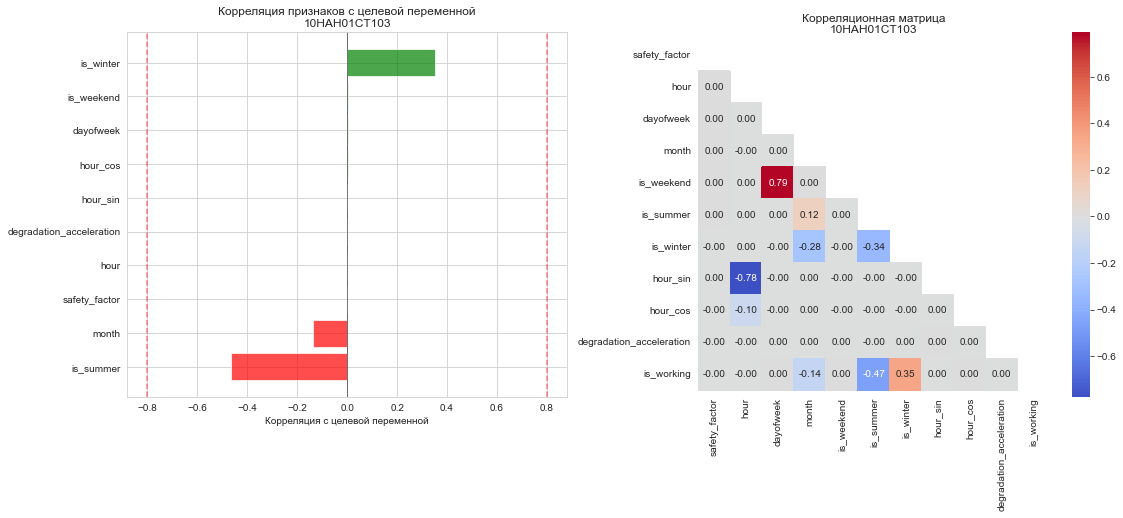


ОТЧЕТ ОБ УДАЛЕННЫХ ПРИЗНАКАХ

10HAH01CT103:
  Удалено из-за высокой корреляции с целевой переменной (> 0.8):
    - temp_median_diff
    - temp_normalized
    - cumulative_degradation_24h
    - degradation_trend_12h
    - degradation_rate

10HAH01CT102:
  Удалено из-за высокой корреляции с целевой переменной (> 0.8):
    - temp_normalized
    - temp_median_diff
    - cumulative_degradation_24h
    - degradation_trend_12h
    - degradation_rate

10HAH12CT101:
  Удалено из-за высокой корреляции с целевой переменной (> 0.8):
    - temp_normalized
    - temp_median_diff
    - cumulative_degradation_24h
    - degradation_trend_12h
    - degradation_rate

10HAH12CT104:
  Удалено из-за высокой корреляции с целевой переменной (> 0.8):
    - temp_median_diff
    - temp_normalized
    - cumulative_degradation_24h
    - degradation_trend_12h
    - degradation_rate

10HAH12CT110:
  Удалено из-за высокой корреляции с целевой переменной (> 0.8):
    - temp_median_diff
    - temp_normalized
    - cum

In [4]:
# ==============================
# ЯЧЕЙКА 4: СОЗДАНИЕ ПРИЗНАКОВ (ПОЛНЫЙ КЛАСС)
# ==============================

class PerSensorFeatureEngineer:
    """Создание признаков для каждого датчика отдельно с удалением коррелированных признаков"""
    
    def __init__(self, physics_model, correlation_threshold_target=0.8, correlation_threshold_features=0.9):
        self.physics_model = physics_model
        self.correlation_threshold_target = correlation_threshold_target
        self.correlation_threshold_features = correlation_threshold_features
        self.removed_features = {}
        self.features_analysis = {}
        self.correlation_matrices = {}
    
    def create_features_for_sensor(self, sensor_name, sensor_df):
        """Создание признаков для конкретного датчика"""
        features_df = sensor_df.copy()
        temp_col = f'{sensor_name}_temp'
        
        has_target = 'is_working' in features_df.columns
        
        # Деградационные признаки с защитой от бесконечных значений
        def safe_degradation_rate(x):
            try:
                return self.physics_model.calculate_degradation_rate(sensor_name, x)
            except:
                return 0.0
        
        features_df['degradation_rate'] = features_df[temp_col].apply(safe_degradation_rate)
        
        window_size = 144
        if len(features_df) > window_size:
            features_df['cumulative_degradation_24h'] = features_df['degradation_rate'].rolling(
                window_size, min_periods=1
            ).sum()
        else:
            features_df['cumulative_degradation_24h'] = features_df['degradation_rate'].cumsum()
        
        # Защита от бесконечных значений в safety_factor
        def safe_safety_factor(row):
            try:
                return self.physics_model.calculate_safety_factor(
                    sensor_name, 
                    row[temp_col], 
                    row['cumulative_degradation_24h']
                )
            except:
                return 1.0  # Значение по умолчанию
        
        features_df['safety_factor'] = features_df.apply(safe_safety_factor, axis=1)
        
        # Ограничиваем слишком большие значения
        features_df['safety_factor'] = features_df['safety_factor'].clip(upper=1000, lower=0.001)
        
        # Временные признаки
        features_df['hour'] = features_df.index.hour
        features_df['dayofweek'] = features_df.index.dayofweek
        features_df['month'] = features_df.index.month
        features_df['is_weekend'] = (features_df['dayofweek'] >= 5).astype(int)
        features_df['is_summer'] = features_df['month'].isin([6, 7, 8]).astype(int)
        features_df['is_winter'] = features_df['month'].isin([12, 1, 2]).astype(int)
        features_df['hour_sin'] = np.sin(2 * np.pi * features_df['hour'] / 24)
        features_df['hour_cos'] = np.cos(2 * np.pi * features_df['hour'] / 24)
        
        # Статистические признаки
        features_df['degradation_trend_12h'] = features_df['degradation_rate'].rolling(72, min_periods=1).mean()
        features_df['degradation_acceleration'] = features_df['degradation_rate'].diff().fillna(0)
        
        # Признаки состояния
        if temp_col in features_df.columns:
            df_median = features_df[temp_col].median()
            df_mean = features_df[temp_col].mean()
            df_std = features_df[temp_col].std()
            
            features_df['temp_median_diff'] = features_df[temp_col] - df_median
            if df_std > 0:
                features_df['temp_normalized'] = (features_df[temp_col] - df_mean) / df_std
            else:
                features_df['temp_normalized'] = 0
        
        # Удаляем прямые температурные признаки
        features_for_model = features_df.drop(columns=[temp_col], errors='ignore')
        
        # Заменяем бесконечные значения на конечные
        numeric_cols = features_for_model.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            # Заменяем бесконечности на NaN
            features_for_model[col] = features_for_model[col].replace([np.inf, -np.inf], np.nan)
            # Заполняем пропуски медианой
            if features_for_model[col].isna().any():
                median_val = features_for_model[col].median()
                features_for_model[col] = features_for_model[col].fillna(median_val)
        
        # УДАЛЕНИЕ КОРРЕЛИРОВАННЫХ ПРИЗНАКОВ
        if has_target:
            features_for_model = self._check_and_remove_correlated_features(
                sensor_name, features_for_model
            )
        
        # Анализ признаков
        self._analyze_sensor_features(sensor_name, features_for_model)
        
        # Сохраняем матрицу корреляций
        if has_target:
            self._save_correlation_matrix(sensor_name, features_for_model)
        
        print(f"  {sensor_name}: создано {len(features_for_model.columns)} признаков")
        return features_for_model, features_df
    
    def _check_and_remove_correlated_features(self, sensor_name, features_df):
        """Проверка и удаление признаков с высокой корреляцией"""
        if 'is_working' not in features_df.columns:
            return features_df
        
        original_features = features_df.columns.tolist()
        removed_features_list = []
        
        # 1. Удаление признаков с высокой корреляцией с целевой переменной (> 0.8)
        target_corr = features_df.corr()['is_working'].abs().sort_values(ascending=False)
        target_corr = target_corr.drop('is_working', errors='ignore')
        
        high_corr_with_target = target_corr[target_corr > self.correlation_threshold_target].index.tolist()
        
        if high_corr_with_target:
            print(f"    Удаляем признаки с высокой корреляцией с целевой переменной (> {self.correlation_threshold_target}): {high_corr_with_target}")
            
            self.removed_features[sensor_name] = {
                'target_correlated': high_corr_with_target,
                'target_correlations': target_corr[high_corr_with_target].to_dict()
            }
            
            features_df = features_df.drop(columns=high_corr_with_target)
            removed_features_list.extend(high_corr_with_target)
        
        # 2. Удаление сильно коррелированных между собой признаков (> 0.9)
        if 'is_working' in features_df.columns:
            feature_cols = [col for col in features_df.columns if col != 'is_working']
        else:
            feature_cols = features_df.columns.tolist()
        
        if len(feature_cols) >= 2:
            features_to_remove = self._remove_high_interfeature_correlation(
                sensor_name, features_df, feature_cols
            )
            
            if features_to_remove:
                features_df = features_df.drop(columns=features_to_remove)
                removed_features_list.extend(features_to_remove)
                
                if sensor_name in self.removed_features:
                    self.removed_features[sensor_name]['interfeature_correlated'] = features_to_remove
                else:
                    self.removed_features[sensor_name] = {
                        'interfeature_correlated': features_to_remove
                    }
        
        if removed_features_list:
            print(f"    Всего удалено {len(removed_features_list)} признаков")
        
        return features_df
    
    def _remove_high_interfeature_correlation(self, sensor_name, features_df, feature_cols):
        """Удаление признаков с высокой межпризнаковой корреляцией"""
        corr_matrix = features_df[feature_cols].corr().abs()
        
        features_to_remove = set()
        n_features = len(corr_matrix.columns)
        
        for i in range(n_features):
            if corr_matrix.columns[i] in features_to_remove:
                continue
            for j in range(i+1, n_features):
                if corr_matrix.columns[j] in features_to_remove:
                    continue
                    
                if corr_matrix.iloc[i, j] > self.correlation_threshold_features:
                    feature_i = corr_matrix.columns[i]
                    feature_j = corr_matrix.columns[j]
                    
                    if 'is_working' in features_df.columns:
                        corr_i = abs(features_df[feature_i].corr(features_df['is_working']))
                        corr_j = abs(features_df[feature_j].corr(features_df['is_working']))
                        
                        if corr_i < corr_j:
                            features_to_remove.add(feature_i)
                        else:
                            features_to_remove.add(feature_j)
                    else:
                        features_to_remove.add(feature_j)
        
        return list(features_to_remove)
    
    def _analyze_sensor_features(self, sensor_name, features_df):
        """Анализ признаков для датчика"""
        if 'is_working' in features_df.columns:
            feature_names = [col for col in features_df.columns if col != 'is_working']
        else:
            feature_names = features_df.columns.tolist()
        
        degradation = [f for f in feature_names if 'degradation' in f.lower()]
        safety = [f for f in feature_names if 'safety' in f.lower()]
        time_features = [f for f in feature_names if any(x in f.lower() for x in ['hour', 'day', 'month', 'week', 'sin', 'cos'])]
        statistical = [f for f in feature_names if any(x in f.lower() for x in ['mean', 'median', 'std', 'diff', 'trend', 'normalized', 'acceleration'])]
        state = [f for f in feature_names if 'temp' in f.lower()]
        other = [f for f in feature_names if f not in degradation + safety + time_features + statistical + state]
        
        self.features_analysis[sensor_name] = {
            'total': len(feature_names),
            'degradation': degradation,
            'safety': safety,
            'time': time_features,
            'statistical': statistical,
            'state': state,
            'other': other,
            'feature_names': feature_names
        }
    
    def _save_correlation_matrix(self, sensor_name, features_df):
        """Сохранение матрицы корреляций"""
        if 'is_working' not in features_df.columns:
            return
        
        feature_cols = [col for col in features_df.columns if col != 'is_working']
        if len(feature_cols) > 0:
            corr_matrix = features_df[feature_cols + ['is_working']].corr()
            self.correlation_matrices[sensor_name] = corr_matrix
    
    def create_features_for_all_sensors(self, sensor_data_dict):
        """Создание признаков для всех датчиков"""
        print("\n" + "="*60)
        print("СОЗДАНИЕ ПРИЗНАКОВ ДЛЯ ВСЕХ ДАТЧИКОВ")
        print(f"Порог корреляции с целевой переменной: {self.correlation_threshold_target}")
        print(f"Порог межпризнаковой корреляции: {self.correlation_threshold_features}")
        print("="*60)
        
        features_dict = {}
        full_features_dict = {}
        
        for sensor_name, sensor_df in sensor_data_dict.items():
            if len(sensor_df) > 0:
                try:
                    features, full_features = self.create_features_for_sensor(sensor_name, sensor_df)
                    features_dict[sensor_name] = features
                    full_features_dict[sensor_name] = full_features
                except Exception as e:
                    print(f"  Ошибка для {sensor_name}: {str(e)[:100]}")
            else:
                print(f"  Пропущен {sensor_name}: нет данных")
        
        print(f"\nСоздано признаков для {len(features_dict)} датчиков")
        return features_dict, full_features_dict
    
    def visualize_correlations(self, sensor_name):
        """Визуализация корреляций"""
        if sensor_name not in self.correlation_matrices:
            return
        
        corr_matrix = self.correlation_matrices[sensor_name]
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # График корреляций с целевой переменной
        if 'is_working' in corr_matrix.columns:
            target_corr = corr_matrix['is_working'].drop('is_working', errors='ignore')
            if len(target_corr) > 0:
                target_corr_sorted = target_corr.sort_values()
                
                colors = ['red' if c < 0 else 'green' for c in target_corr_sorted.values]
                axes[0].barh(range(len(target_corr_sorted)), target_corr_sorted.values, color=colors, alpha=0.7)
                axes[0].set_yticks(range(len(target_corr_sorted)))
                axes[0].set_yticklabels(target_corr_sorted.index)
                axes[0].set_xlabel('Корреляция с целевой переменной')
                axes[0].set_title(f'Корреляция признаков с целевой переменной\n{sensor_name}')
                axes[0].axvline(x=0, color='black', linewidth=0.5)
                axes[0].axvline(x=self.correlation_threshold_target, color='red', linestyle='--', alpha=0.5)
                axes[0].axvline(x=-self.correlation_threshold_target, color='red', linestyle='--', alpha=0.5)
        
        # Тепловая карта корреляций
        if len(corr_matrix.columns) <= 20:
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
            sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
                       annot=True, fmt='.2f', square=True, ax=axes[1])
            axes[1].set_title(f'Корреляционная матрица\n{sensor_name}')
        
        plt.tight_layout()
        plt.show()
    
    def get_removed_features_report(self):
        """Отчет об удаленных признаках"""
        if not self.removed_features:
            print("Ни один признак не был удален")
            return
        
        print("\n" + "="*60)
        print("ОТЧЕТ ОБ УДАЛЕННЫХ ПРИЗНАКАХ")
        print("="*60)
        
        for sensor_name, removal_info in self.removed_features.items():
            print(f"\n{sensor_name}:")
            
            if 'target_correlated' in removal_info and removal_info['target_correlated']:
                print(f"  Удалено из-за высокой корреляции с целевой переменной (> {self.correlation_threshold_target}):")
                for feature in removal_info['target_correlated']:
                    print(f"    - {feature}")
            
            if 'interfeature_correlated' in removal_info and removal_info['interfeature_correlated']:
                print(f"  Удалено из-за высокой межпризнаковой корреляции (> {self.correlation_threshold_features}):")
                for feature in removal_info['interfeature_correlated']:
                    print(f"    - {feature}")

# Создание признаков
print("="*60)
print("СОЗДАНИЕ ПРИЗНАКОВ С УДАЛЕНИЕМ КОРРЕЛИРОВАННЫХ ПРИЗНАКОВ")
print("="*60)

feature_engineer = PerSensorFeatureEngineer(
    physics_model=physics_model, 
    correlation_threshold_target=0.8,
    correlation_threshold_features=0.9
)

sensor_features_dict, sensor_full_features_dict = feature_engineer.create_features_for_all_sensors(
    processor.sensor_data
)

# Проверяем данные
print("\n" + "="*60)
print("ПРОВЕРКА ДАННЫХ")
print("="*60)

for sensor_name, features_df in sensor_features_dict.items():
    numeric_cols = features_df.select_dtypes(include=[np.number]).columns
    
    has_inf = False
    for col in numeric_cols:
        if features_df[col].apply(lambda x: np.isinf(x) if isinstance(x, (int, float)) else False).any():
            has_inf = True
            print(f"⚠️  {sensor_name}: колонка {col} содержит бесконечные значения")
    
    has_nan = features_df[numeric_cols].isna().any().any()
    
    if not has_inf and not has_nan:
        print(f"✓ {sensor_name}: данные чистые (признаков: {len(features_df.columns)})")
    elif has_nan:
        print(f"⚠️  {sensor_name}: содержит NaN значения")

# Визуализация корреляций для первого датчика
if sensor_features_dict:
    first_sensor = list(sensor_features_dict.keys())[0]
    print(f"\nВизуализация корреляций для {first_sensor}:")
    feature_engineer.visualize_correlations(first_sensor)

# Отчет об удаленных признаках
feature_engineer.get_removed_features_report()

In [5]:
# ==============================
# ЯЧЕЙКА 5: ПОДГОТОВКА ДАННЫХ ДЛЯ PYTORCH
# ==============================

class TorchDataPreparator:
    """Подготовка данных для PyTorch с обработкой аномальных значений"""
    
    def __init__(self, test_size=0.25, batch_size=32, random_state=42):
        self.test_size = test_size
        self.batch_size = batch_size
        self.random_state = random_state
        self.sensor_scalers = {}
        self.sensor_datasets = {}
        self.feature_names = {}
        
    def _clean_data(self, X):
        """Очистка данных от бесконечных и NaN значений"""
        X = np.array(X, dtype=np.float32)
        
        # Заменяем бесконечности
        X[np.isinf(X) & (X > 0)] = 1e6
        X[np.isinf(X) & (X < 0)] = -1e6
        
        # Заменяем NaN на медиану столбца
        for i in range(X.shape[1]):
            col = X[:, i]
            nan_mask = np.isnan(col)
            if np.any(nan_mask):
                col_median = np.nanmedian(col)
                col[nan_mask] = col_median
                X[:, i] = col
        
        return X
    
    def prepare_sensor_data(self, sensor_name, features_df, target_col='is_working'):
        """Подготовка данных для конкретного датчика"""
        if target_col not in features_df.columns:
            print(f"  {sensor_name}: нет целевой переменной '{target_col}'")
            return None
        
        # Отделяем целевую переменную
        y = features_df[target_col].copy().values.astype(np.float32)
        X = features_df.drop(columns=[target_col]).copy()
        
        # Очищаем признаки
        X_cleaned = self._clean_data(X.values)
        
        # Разделение с учетом временных рядов
        split_idx = int(len(X_cleaned) * (1 - self.test_size))
        
        X_train = X_cleaned[:split_idx]
        X_test = X_cleaned[split_idx:]
        y_train = y[:split_idx]
        y_test = y[split_idx:]
        
        # Проверяем данные
        if len(X_train) == 0 or len(X_test) == 0:
            print(f"  {sensor_name}: недостаточно данных")
            return None
        
        # Дополнительная очистка
        if np.any(np.isinf(X_train)) or np.any(np.isinf(X_test)):
            X_train = np.nan_to_num(X_train, nan=0.0, posinf=1e6, neginf=-1e6)
            X_test = np.nan_to_num(X_test, nan=0.0, posinf=1e6, neginf=-1e6)
        
        # Масштабирование
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Проверяем масштабированные данные
        if np.any(np.isnan(X_train_scaled)) or np.any(np.isnan(X_test_scaled)):
            X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
            X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)
        
        # Сохраняем скалер и названия признаков
        self.sensor_scalers[sensor_name] = scaler
        self.feature_names[sensor_name] = features_df.drop(columns=[target_col]).columns.tolist()
        
        # Создаем PyTorch Dataset
        train_dataset = TensorDataset(
            torch.FloatTensor(X_train_scaled),
            torch.FloatTensor(y_train).unsqueeze(1)
        )
        
        test_dataset = TensorDataset(
            torch.FloatTensor(X_test_scaled),
            torch.FloatTensor(y_test).unsqueeze(1)
        )
        
        # Создаем DataLoader
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, 
                                 shuffle=True, num_workers=0, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, 
                                shuffle=False, num_workers=0, pin_memory=True)
        
        prepared_data = {
            'train_loader': train_loader,
            'test_loader': test_loader,
            'X_train': X_train_scaled,
            'X_test': X_test_scaled,
            'y_train': y_train,
            'y_test': y_test,
            'feature_names': self.feature_names[sensor_name],
            'scaler': scaler
        }
        
        self.sensor_datasets[sensor_name] = prepared_data
        
        print(f"  {sensor_name}: {len(X_train)} train, {len(X_test)} test, "
              f"{X_train.shape[1]} features")
        
        return prepared_data
    
    def prepare_all_sensors(self, features_dict, max_sensors=None):
        """Подготовка данных для всех датчиков"""
        print("\n" + "="*60)
        print("ПОДГОТОВКА ДАННЫХ ДЛЯ PYTORCH")
        print("="*60)
        
        sensors = list(features_dict.keys())[:max_sensors] if max_sensors else list(features_dict.keys())
        prepared_count = 0
        
        for i, sensor_name in enumerate(sensors, 1):
            print(f"[{i}/{len(sensors)}] ", end="")
            features_df = features_dict[sensor_name]
            
            if features_df.empty:
                print(f"{sensor_name}: пустой DataFrame")
                continue
            
            prepared_data = self.prepare_sensor_data(sensor_name, features_df)
            if prepared_data is not None:
                prepared_count += 1
        
        print(f"\n✓ Подготовлено {prepared_count}/{len(sensors)} датчиков")
        
        # Статистика
        print("\n📊 Статистика подготовки данных:")
        for sensor_name, data in self.sensor_datasets.items():
            X_train = data['X_train']
            print(f"  {sensor_name}: train shape={X_train.shape}, "
                  f"min={X_train.min():.2f}, max={X_train.max():.2f}")
        
        return self.sensor_datasets

# Подготовка данных для PyTorch
print("="*60)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ PYTORCH")
print("="*60)

torch_preparator = TorchDataPreparator(
    test_size=0.25,
    batch_size=64,
    random_state=42
)

sensor_datasets = torch_preparator.prepare_all_sensors(
    sensor_features_dict,
    max_sensors=11  # Все датчики
)

# Проверяем первый датчик
if sensor_datasets:
    first_sensor = list(sensor_datasets.keys())[0]
    dataset = sensor_datasets[first_sensor]
    print(f"\nПроверка данных для {first_sensor}:")
    print(f"  Размер X_train: {dataset['X_train'].shape}")
    print(f"  Размер X_test: {dataset['X_test'].shape}")
    print(f"  Признаков: {len(dataset['feature_names'])}")
    print(f"  Пример признаков: {dataset['feature_names'][:5]}")

ПОДГОТОВКА ДАННЫХ ДЛЯ PYTORCH

ПОДГОТОВКА ДАННЫХ ДЛЯ PYTORCH
[1/11]   10HAH01CT103: 227604 train, 75869 test, 10 features
[2/11]   10HAH01CT102: 227604 train, 75869 test, 10 features
[3/11]   10HAH12CT101: 227604 train, 75869 test, 10 features
[4/11]   10HAH12CT104: 227604 train, 75869 test, 10 features
[5/11]   10HAH12CT110: 227604 train, 75869 test, 10 features
[6/11]   10HAH12CT108: 227604 train, 75869 test, 10 features
[7/11]   10HAH12CT106: 227604 train, 75869 test, 11 features
[8/11]   10HAH11CT114: 227604 train, 75869 test, 10 features
[9/11]   10HAH11CT113: 227604 train, 75869 test, 11 features
[10/11]   10HAH12CT116: 227604 train, 75869 test, 10 features
[11/11]   10HAH12CT117: 227604 train, 75869 test, 10 features

✓ Подготовлено 11/11 датчиков

📊 Статистика подготовки данных:
  10HAH01CT103: train shape=(227604, 10), min=-337.34, max=70.62
  10HAH01CT102: train shape=(227604, 10), min=-477.08, max=38.46
  10HAH12CT101: train shape=(227604, 10), min=-337.34, max=42.60
  10HAH

ОБУЧЕНИЕ НЕЙРОННЫХ СЕТЕЙ
ОБУЧЕНИЕ НЕЙРОННЫХ СЕТЕЙ НА PYTORCH
Устройство: cpu
Эпох: 100, Batch size: определяется в DataLoader
[1/11] 
🎯 Обучение модели для 10HAH01CT103...
    Эпоха 10/100: Train Loss: 0.2490, Val Loss: 0.4758, Val AUC: 0.8721
    Эпоха 20/100: Train Loss: 0.2410, Val Loss: 0.5296, Val AUC: 0.8739
    Эпоха 30/100: Train Loss: 0.2387, Val Loss: 0.5641, Val AUC: 0.8722
    Эпоха 40/100: Train Loss: 0.2373, Val Loss: 0.5165, Val AUC: 0.8682
    Ранняя остановка на эпохе 42
    ✓ Обучение завершено. Лучший Val AUC: 0.8818
[2/11] 
🎯 Обучение модели для 10HAH01CT102...
    Эпоха 10/100: Train Loss: 0.2486, Val Loss: 0.4587, Val AUC: 0.8755
    Эпоха 20/100: Train Loss: 0.2412, Val Loss: 0.4476, Val AUC: 0.8785
    Эпоха 30/100: Train Loss: 0.2365, Val Loss: 0.4768, Val AUC: 0.8805
    Ранняя остановка на эпохе 40
    ✓ Обучение завершено. Лучший Val AUC: 0.8832
[3/11] 
🎯 Обучение модели для 10HAH12CT101...
    Эпоха 10/100: Train Loss: 0.2455, Val Loss: 0.5015, Val AUC: 0.8

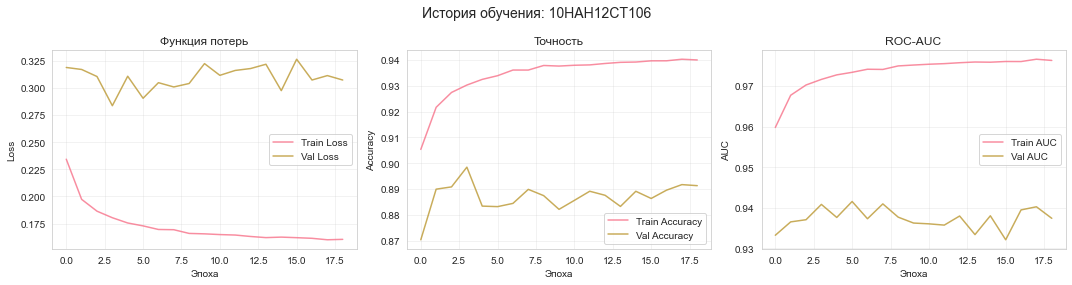

In [7]:
# ==============================
# ЯЧЕЙКА 6: НЕЙРОННАЯ СЕТЬ НА PYTORCH (ИСПРАВЛЕННАЯ)
# ==============================

class BoilerClassifier(nn.Module):
    """Нейронная сеть для классификации состояния котла"""
    
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], dropout_rate=0.3):
        super(BoilerClassifier, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Динамическое создание слоев
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Выходной слой
        layers.append(nn.Linear(prev_size, 1))
        
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return torch.sigmoid(self.model(x))

class EarlyStopping:
    """Ранняя остановка для предотвращения переобучения"""
    
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

class TorchBoilerTrainer:
    """Тренировка нейронной сети для датчиков котла"""
    
    def __init__(self, device, n_epochs=100, lr=0.001, weight_decay=1e-5, classification_threshold=0.5):
        self.device = device
        self.n_epochs = n_epochs
        self.lr = lr
        self.weight_decay = weight_decay
        self.classification_threshold = classification_threshold
        self.sensor_models = {}
        self.training_history = {}
        
    def train_sensor_model(self, sensor_name, train_loader, test_loader, input_size):
        """Обучение модели для одного датчика"""
        print(f"\n🎯 Обучение модели для {sensor_name}...")
        
        # Создаем модель
        model = BoilerClassifier(input_size=input_size).to(self.device)
        
        # Функции потерь и оптимизатор
        criterion = nn.BCELoss()
        optimizer = optim.AdamW(model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        
        # Скалер для mixed precision training
        scaler = GradScaler() if self.device.type == 'cuda' else None
        
        # Ранняя остановка
        early_stopping = EarlyStopping(patience=15, min_delta=0.001)
        
        # История обучения
        history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
            'train_auc': [],
            'val_auc': []
        }
        
        # Обучение
        best_val_loss = float('inf')
        best_model_state = None
        
        for epoch in range(self.n_epochs):
            # Тренировочный этап
            model.train()
            train_loss = 0.0
            train_preds = []
            train_targets = []
            
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                
                if scaler is not None:
                    # Mixed precision training для GPU
                    with autocast():
                        outputs = model(batch_X)
                        loss = criterion(outputs, batch_y)
                    
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    optimizer.step()
                
                train_loss += loss.item() * batch_X.size(0)
                train_preds.extend(outputs.detach().cpu().numpy())
                train_targets.extend(batch_y.cpu().numpy())
            
            train_loss = train_loss / len(train_loader.dataset)
            train_preds = np.array(train_preds).flatten()
            train_targets = np.array(train_targets).flatten()
            
            # Бинаризация для метрик
            train_targets_binary = (train_targets > self.classification_threshold).astype(int)
            train_preds_binary = (train_preds > self.classification_threshold).astype(int)
            
            train_acc = accuracy_score(train_targets_binary, train_preds_binary)
            
            # Проверяем, есть ли оба класса
            if len(np.unique(train_targets_binary)) == 2:
                train_auc = roc_auc_score(train_targets_binary, train_preds)
            else:
                train_auc = 0.5  # Значение по умолчанию, если только один класс
            
            # Валидационный этап
            model.eval()
            val_loss = 0.0
            val_preds = []
            val_targets = []
            
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    
                    val_loss += loss.item() * batch_X.size(0)
                    val_preds.extend(outputs.cpu().numpy())
                    val_targets.extend(batch_y.cpu().numpy())
            
            val_loss = val_loss / len(test_loader.dataset)
            val_preds = np.array(val_preds).flatten()
            val_targets = np.array(val_targets).flatten()
            
            # Бинаризация для метрик
            val_targets_binary = (val_targets > self.classification_threshold).astype(int)
            val_preds_binary = (val_preds > self.classification_threshold).astype(int)
            
            val_acc = accuracy_score(val_targets_binary, val_preds_binary)
            
            # Проверяем, есть ли оба класса
            if len(np.unique(val_targets_binary)) == 2:
                val_auc = roc_auc_score(val_targets_binary, val_preds)
            else:
                val_auc = 0.5
            
            # Сохранение истории
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            history['train_auc'].append(train_auc)
            history['val_auc'].append(val_auc)
            
            # Сохранение лучшей модели
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict().copy()
            
            # Ранняя остановка
            if early_stopping(val_loss):
                print(f"    Ранняя остановка на эпохе {epoch+1}")
                break
            
            # Прогресс каждые 10 эпох
            if (epoch + 1) % 10 == 0:
                print(f"    Эпоха {epoch+1}/{self.n_epochs}: "
                      f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
                      f"Val AUC: {val_auc:.4f}")
        
        # Загружаем лучшую модель
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
        
        # Сохраняем модель и историю
        self.sensor_models[sensor_name] = {
            'model': model,
            'history': history,
            'best_val_loss': best_val_loss,
            'best_val_auc': max(history['val_auc']) if history['val_auc'] else 0.5,
            'input_size': input_size
        }
        
        self.training_history[sensor_name] = history
        
        print(f"    ✓ Обучение завершено. Лучший Val AUC: {max(history['val_auc']):.4f}")
        
        return model
    
    def train_all_sensors(self, sensor_datasets, max_sensors=None):
        """Обучение моделей для всех датчиков"""
        print("="*60)
        print("ОБУЧЕНИЕ НЕЙРОННЫХ СЕТЕЙ НА PYTORCH")
        print("="*60)
        print(f"Устройство: {self.device}")
        print(f"Эпох: {self.n_epochs}, Batch size: определяется в DataLoader")
        print("="*60)
        
        sensors = list(sensor_datasets.keys())[:max_sensors] if max_sensors else list(sensor_datasets.keys())
        
        for i, sensor_name in enumerate(sensors, 1):
            dataset = sensor_datasets.get(sensor_name)
            if not dataset:
                continue
            
            input_size = dataset['X_train'].shape[1]
            
            # Проверяем баланс классов
            y_train_binary = (dataset['y_train'] > self.classification_threshold).astype(int)
            class_counts = np.bincount(y_train_binary)
            
            if len(class_counts) < 2:
                print(f"⚠️  {sensor_name}: только один класс в обучающих данных. Пропускаем.")
                continue
            
            print(f"[{i}/{len(sensors)}] ", end="")
            model = self.train_sensor_model(
                sensor_name,
                dataset['train_loader'],
                dataset['test_loader'],
                input_size
            )
        
        print(f"\n✓ Обучено: {len(self.sensor_models)}/{len(sensors)} датчиков")
        return self.sensor_models
    
    def plot_training_history(self, sensor_name):
        """Визуализация истории обучения"""
        if sensor_name not in self.training_history:
            print(f"Нет истории обучения для {sensor_name}")
            return
        
        history = self.training_history[sensor_name]
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'История обучения: {sensor_name}', fontsize=14)
        
        # Loss
        axes[0].plot(history['train_loss'], label='Train Loss', alpha=0.8)
        axes[0].plot(history['val_loss'], label='Val Loss', alpha=0.8)
        axes[0].set_xlabel('Эпоха')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Функция потерь')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Accuracy
        axes[1].plot(history['train_acc'], label='Train Accuracy', alpha=0.8)
        axes[1].plot(history['val_acc'], label='Val Accuracy', alpha=0.8)
        axes[1].set_xlabel('Эпоха')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Точность')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # AUC
        axes[2].plot(history['train_auc'], label='Train AUC', alpha=0.8)
        axes[2].plot(history['val_auc'], label='Val AUC', alpha=0.8)
        axes[2].set_xlabel('Эпоха')
        axes[2].set_ylabel('AUC')
        axes[2].set_title('ROC-AUC')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def get_training_summary(self):
        """Сводка по обучению"""
        if not self.sensor_models:
            print("Нет обученных моделей")
            return []
        
        summary = []
        for sensor_name, model_info in self.sensor_models.items():
            history = model_info['history']
            summary.append({
                'sensor': sensor_name,
                'best_val_auc': model_info['best_val_auc'],
                'best_val_loss': model_info['best_val_loss'],
                'final_train_auc': history['train_auc'][-1] if history['train_auc'] else 0.5,
                'final_val_auc': history['val_auc'][-1] if history['val_auc'] else 0.5,
                'input_size': model_info['input_size']
            })
        
        # Сортировка по AUC
        summary_sorted = sorted(summary, key=lambda x: x['best_val_auc'], reverse=True)
        
        print("\n" + "="*60)
        print("СВОДКА ПО ОБУЧЕНИЮ PYTORCH МОДЕЛЕЙ")
        print("="*60)
        
        print(f"\n{'Датчик':<20} {'Val AUC':<10} {'Val Loss':<12} {'Input Size':<12}")
        print("-" * 60)
        
        for item in summary_sorted:
            print(f"{item['sensor']:<20} "
                  f"{item['best_val_auc']:<10.4f} "
                  f"{item['best_val_loss']:<12.4f} "
                  f"{item['input_size']:<12}")
        
        # Статистика
        if summary_sorted:
            auc_values = [s['best_val_auc'] for s in summary_sorted]
            loss_values = [s['best_val_loss'] for s in summary_sorted]
            
            print(f"\n📊 Статистика:")
            print(f"  Средний AUC: {np.mean(auc_values):.4f} ± {np.std(auc_values):.4f}")
            print(f"  Средний Loss: {np.mean(loss_values):.4f} ± {np.std(loss_values):.4f}")
            print(f"  Лучший AUC: {max(auc_values):.4f}")
            print(f"  Худший AUC: {min(auc_values):.4f}")
        
        return summary_sorted

# Обучение моделей
print("="*60)
print("ОБУЧЕНИЕ НЕЙРОННЫХ СЕТЕЙ")
print("="*60)

torch_trainer = TorchBoilerTrainer(
    device=device,
    n_epochs=100,
    lr=0.001,
    weight_decay=1e-5,
    classification_threshold=0.5
)

trained_torch_models = torch_trainer.train_all_sensors(
    sensor_datasets,
    max_sensors=11  # Все датчики
)

# Сводка по обучению
if trained_torch_models:
    summary = torch_trainer.get_training_summary()
    
    # Визуализация для первого датчика
    if summary:
        best_sensor = summary[0]['sensor']
        print(f"\n📊 Визуализация истории обучения для лучшего датчика: {best_sensor}")
        torch_trainer.plot_training_history(best_sensor)

ТЕСТИРОВАНИЕ PYTORCH МОДЕЛЕЙ
ТЕСТИРОВАНИЕ PYTORCH МОДЕЛЕЙ
🔍 Тестирование 10HAH01CT103: AUC=0.8818, F1=0.8291
🔍 Тестирование 10HAH01CT102: AUC=0.8522, F1=0.8098
🔍 Тестирование 10HAH12CT101: AUC=0.8806, F1=0.8457
🔍 Тестирование 10HAH12CT104: AUC=0.8814, F1=0.8374
🔍 Тестирование 10HAH12CT110: AUC=0.8745, F1=0.8253
🔍 Тестирование 10HAH12CT108: AUC=0.8998, F1=0.8632
🔍 Тестирование 10HAH12CT106: AUC=0.9374, F1=0.9137
🔍 Тестирование 10HAH11CT114: AUC=0.8813, F1=0.8371
🔍 Тестирование 10HAH11CT113: AUC=0.8899, F1=0.8976
🔍 Тестирование 10HAH12CT116: AUC=0.8783, F1=0.8276
🔍 Тестирование 10HAH12CT117: AUC=0.8808, F1=0.8262

✓ Протестировано: 11/11 моделей

РЕЗУЛЬТАТЫ PYTORCH МОДЕЛЕЙ НА ТЕСТЕ

Датчик               AUC      F1       Accuracy   Precision  Recall    
----------------------------------------------------------------------
10HAH12CT106         0.9374   0.9137   0.8913     0.9700     0.8636    
10HAH12CT108         0.8998   0.8632   0.8340     0.9580     0.7854    
10HAH11CT113         0.

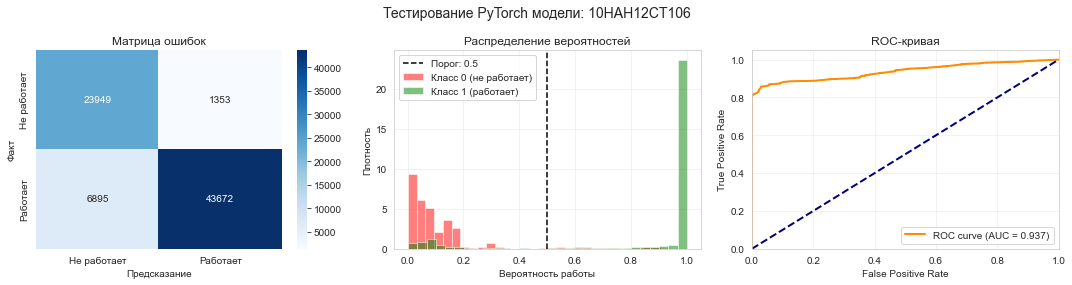

In [12]:
# ==============================
# ЯЧЕЙКА 7: ТЕСТИРОВАНИЕ МОДЕЛЕЙ
# ==============================

class TorchModelTester:
    """Тестирование PyTorch моделей"""
    
    def __init__(self, device):
        self.device = device
        self.test_results = {}
        
    def test_sensor_model(self, sensor_name, model_info, test_loader, y_test_np):
        """Тестирование модели для одного датчика"""
        print(f"🔍 Тестирование {sensor_name}: ", end="")
        
        try:
            model = model_info['model']
            model.eval()
            
            all_preds = []
            all_probs = []
            
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X = batch_X.to(self.device)
                    outputs = model(batch_X)
                    all_probs.extend(outputs.cpu().numpy().flatten())
                    all_preds.extend((outputs.cpu().numpy().flatten() > 0.5).astype(int))
            
            y_pred_proba = np.array(all_probs)
            y_pred = np.array(all_preds)
            y_test_binary = (y_test_np > 0.5).astype(int)
            
            # Метрики
            metrics = {
                'accuracy': accuracy_score(y_test_binary, y_pred),
                'precision': precision_score(y_test_binary, y_pred, zero_division=0),
                'recall': recall_score(y_test_binary, y_pred, zero_division=0),
                'f1': f1_score(y_test_binary, y_pred, zero_division=0),
                'roc_auc': roc_auc_score(y_test_binary, y_pred_proba)
            }
            
            # Confusion matrix
            cm = confusion_matrix(y_test_binary, y_pred)
            
            self.test_results[sensor_name] = {
                'metrics': metrics,
                'confusion_matrix': cm,
                'y_test': y_test_binary,
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba
            }
            
            print(f"AUC={metrics['roc_auc']:.4f}, F1={metrics['f1']:.4f}")
            return metrics
            
        except Exception as e:
            print(f"Ошибка: {str(e)[:50]}")
            return None
    
    def test_all_models(self, trained_models, sensor_datasets):
        """Тестирование всех моделей"""
        print("="*60)
        print("ТЕСТИРОВАНИЕ PYTORCH МОДЕЛЕЙ")
        print("="*60)
        
        tested_count = 0
        
        for sensor_name, model_info in trained_models.items():
            if sensor_name in sensor_datasets:
                dataset = sensor_datasets[sensor_name]
                
                result = self.test_sensor_model(
                    sensor_name,
                    model_info,
                    dataset['test_loader'],
                    dataset['y_test']
                )
                
                if result:
                    tested_count += 1
        
        print(f"\n✓ Протестировано: {tested_count}/{len(trained_models)} моделей")
        return self.test_results
    
    def get_test_summary(self):
        """Сводка по тестированию"""
        if not self.test_results:
            print("Нет результатов тестирования")
            return []
        
        summary = []
        for sensor_name, result in self.test_results.items():
            metrics = result['metrics']
            summary.append({
                'sensor': sensor_name,
                'test_auc': metrics['roc_auc'],
                'test_f1': metrics['f1'],
                'test_acc': metrics['accuracy'],
                'test_prec': metrics['precision'],
                'test_recall': metrics['recall']
            })
        
        # Сортировка по AUC
        summary_sorted = sorted(summary, key=lambda x: x['test_auc'], reverse=True)
        
        print("\n" + "="*60)
        print("РЕЗУЛЬТАТЫ PYTORCH МОДЕЛЕЙ НА ТЕСТЕ")
        print("="*60)
        
        print(f"\n{'Датчик':<20} {'AUC':<8} {'F1':<8} {'Accuracy':<10} {'Precision':<10} {'Recall':<10}")
        print("-" * 70)
        
        for item in summary_sorted:
            print(f"{item['sensor']:<20} "
                  f"{item['test_auc']:<8.4f} "
                  f"{item['test_f1']:<8.4f} "
                  f"{item['test_acc']:<10.4f} "
                  f"{item['test_prec']:<10.4f} "
                  f"{item['test_recall']:<10.4f}")
        
        # Статистика
        if summary_sorted:
            auc_values = [s['test_auc'] for s in summary_sorted]
            f1_values = [s['test_f1'] for s in summary_sorted]
            
            print(f"\n📊 Статистика на тесте:")
            print(f"  Средний AUC: {np.mean(auc_values):.4f} ± {np.std(auc_values):.4f}")
            print(f"  Средний F1:  {np.mean(f1_values):.4f} ± {np.std(f1_values):.4f}")
            print(f"  Лучший AUC:  {max(auc_values):.4f}")
            print(f"  Худший AUC:  {min(auc_values):.4f}")
        
        return summary_sorted
    
    def visualize_test_results(self, sensor_name):
        """Визуализация результатов тестирования"""
        if sensor_name not in self.test_results:
            print(f"Нет результатов для {sensor_name}")
            return
        
        result = self.test_results[sensor_name]
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'Тестирование PyTorch модели: {sensor_name}', fontsize=14)
        
        # Confusion Matrix
        cm = result['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_xlabel('Предсказание')
        axes[0].set_ylabel('Факт')
        axes[0].set_title('Матрица ошибок')
        axes[0].set_xticklabels(['Не работает', 'Работает'])
        axes[0].set_yticklabels(['Не работает', 'Работает'])
        
        # Распределение вероятностей
        y_test = result['y_test']
        y_pred_proba = result['y_pred_proba']
        
        axes[1].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.5, 
                    label='Класс 0 (не работает)', color='red', density=True)
        axes[1].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.5, 
                    label='Класс 1 (работает)', color='green', density=True)
        axes[1].axvline(x=0.5, color='black', linestyle='--', label='Порог: 0.5')
        axes[1].set_xlabel('Вероятность работы')
        axes[1].set_ylabel('Плотность')
        axes[1].set_title('Распределение вероятностей')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # ROC-кривая
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        axes[2].plot(fpr, tpr, color='darkorange', lw=2, 
                    label=f'ROC curve (AUC = {roc_auc:.3f})')
        axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[2].set_xlim([0.0, 1.0])
        axes[2].set_ylim([0.0, 1.05])
        axes[2].set_xlabel('False Positive Rate')
        axes[2].set_ylabel('True Positive Rate')
        axes[2].set_title('ROC-кривая')
        axes[2].legend(loc="lower right")
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Тестирование моделей
print("="*60)
print("ТЕСТИРОВАНИЕ PYTORCH МОДЕЛЕЙ")
print("="*60)

torch_tester = TorchModelTester(device)
torch_test_results = torch_tester.test_all_models(trained_torch_models, sensor_datasets)
torch_test_summary = torch_tester.get_test_summary()

# Визуализация для лучшего датчика
if torch_test_summary:
    best_sensor = torch_test_summary[0]['sensor']
    print(f"\n📊 Визуализация результатов для лучшего датчика: {best_sensor}")
    torch_tester.visualize_test_results(best_sensor)

СОЗДАНИЕ ИСПРАВЛЕННОЙ ФИЗИЧЕСКОЙ МОДЕЛИ

ЗАПУСК РЕАЛИСТИЧНОГО ПРОГНОЗА ОТКАЗОВ
РЕАЛИСТИЧНЫЙ ПРОГНОЗ ОТКАЗОВ НА ОСНОВЕ ФИЗИКИ

🔍 Анализ риска для 10HAH01CT103:
⏳ Прогноз времени до отказа для 10HAH01CT103...
   ✅ Отказ не прогнозируется в течение 1095 дней
   📊 Минимальный safety factor: 1.92
   ✅ Безопасная работа в течение 3 лет
   📊 Средний safety factor: 1.94
   📉 Минимальный safety factor: 1.92

🔍 Анализ риска для 10HAH01CT102:
⏳ Прогноз времени до отказа для 10HAH01CT102...
   ✅ Отказ не прогнозируется в течение 1095 дней
   📊 Минимальный safety factor: 1.92
   ✅ Безопасная работа в течение 3 лет
   📊 Средний safety factor: 1.94
   📉 Минимальный safety factor: 1.92

🔍 Анализ риска для 10HAH12CT101:
⏳ Прогноз времени до отказа для 10HAH12CT101...
   ✅ Отказ не прогнозируется в течение 1095 дней
   📊 Минимальный safety factor: 1.65
   ✅ Безопасная работа в течение 3 лет
   📊 Средний safety factor: 1.72
   📉 Минимальный safety factor: 1.65

🔍 Анализ риска для 10HAH12CT104:
⏳ Прогноз 

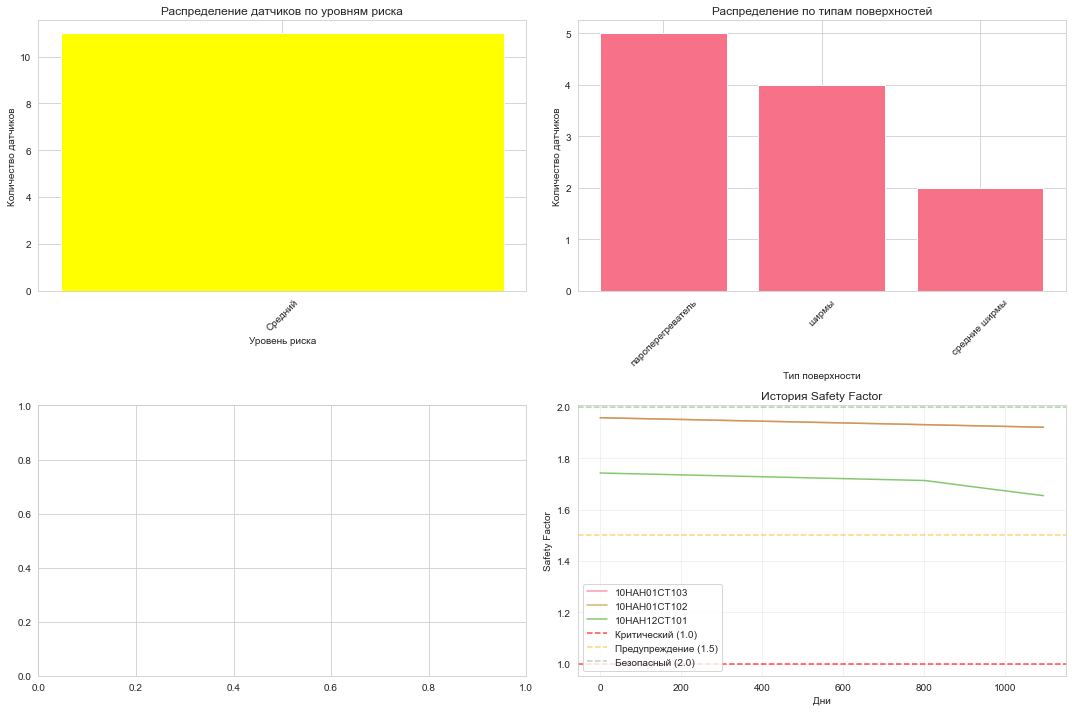


ПЛАН ОБСЛУЖИВАНИЯ НА 2019 ГОД


In [25]:
# ==============================
# ЯЧЕЙКА 11: ИСПРАВЛЕННАЯ ФИЗИЧЕСКАЯ МОДЕЛЬ И ПРОГНОЗ ОТКАЗОВ
# ==============================

class FixedPhysicsModel:
    """Исправленная физическая модель для реалистичных прогнозов"""
    
    def __init__(self, boiler_params):
        self.boiler_params = boiler_params
        self.material_properties = {
            'средние ширмы': {'yield_strength': 235, 'creep_limit': 150, 'fatigue_limit': 120},
            'ширмы': {'yield_strength': 245, 'creep_limit': 160, 'fatigue_limit': 130},
            'пароперегреватель': {'yield_strength': 255, 'creep_limit': 170, 'fatigue_limit': 140}
        }
    
    def calculate_stress(self, sensor_name, temperature, pressure=14):
        """Расчет механического напряжения"""
        sensor_info = SENSORS.get(sensor_name, {})
        surface_type = sensor_info.get('surface_type', 'средние ширмы')
        props = self.material_properties.get(surface_type, self.material_properties['средние ширмы'])
        
        # Базовое напряжение от давления
        base_stress = pressure * 10  # МПа
        
        # Температурная компонента
        if temperature > 400:
            temp_factor = 1 + (temperature - 400) * 0.001
        else:
            temp_factor = 1.0
        
        # Деградационная компонента (имитация старения)
        time_factor = 1.0  # Будет меняться во времени
        
        total_stress = base_stress * temp_factor * time_factor
        
        return min(total_stress, 500)  # Ограничиваем максимальное напряжение
    
    def calculate_material_strength(self, sensor_name, temperature, cumulative_cycles=0):
        """Расчет прочности материала с учетом температуры и усталости"""
        sensor_info = SENSORS.get(sensor_name, {})
        surface_type = sensor_info.get('surface_type', 'средние ширмы')
        props = self.material_properties.get(surface_type, self.material_properties['средние ширмы'])
        
        # Базовая прочность
        base_strength = props['yield_strength']
        
        # Температурная деградация
        if temperature > 300:
            temp_reduction = (temperature - 300) * 0.05
        else:
            temp_reduction = 0
        
        # Усталостная деградация
        fatigue_reduction = cumulative_cycles * 0.001
        
        total_strength = base_strength - temp_reduction - fatigue_reduction
        
        return max(total_strength, 50)  # Минимальная прочность 50 МПа
    
    def calculate_safety_factor(self, sensor_name, temperature, pressure=14, 
                              operating_hours=0, thermal_cycles=0):
        """Расчет коэффициента безопасности"""
        # Текущее напряжение
        current_stress = self.calculate_stress(sensor_name, temperature, pressure)
        
        # Оставшаяся прочность материала
        cumulative_cycles = thermal_cycles + operating_hours / 1000  # 1000 часов = 1 цикл
        material_strength = self.calculate_material_strength(sensor_name, temperature, cumulative_cycles)
        
        # Коэффициент безопасности
        if current_stress > 0:
            safety_factor = material_strength / current_stress
        else:
            safety_factor = 100  # Очень высокий, если нет напряжения
        
        return safety_factor
    
    def predict_failure_time(self, sensor_name, initial_temp=300, temp_increase_rate=0.1, 
                           pressure=14, operating_hours_per_day=24):
        """Прогноз времени до отказа"""
        print(f"⏳ Прогноз времени до отказа для {sensor_name}...")
        
        days = 0
        temperature = initial_temp
        safety_history = []
        time_history = []
        
        # Имитация работы в течение 3 лет
        max_days = 365 * 3
        
        while days < max_days:
            # Увеличение температуры (имитация деградации)
            temperature += temp_increase_rate
            
            # Расчет safety factor
            operating_hours = days * operating_hours_per_day
            thermal_cycles = days / 30  # 1 цикл в месяц
            
            safety = self.calculate_safety_factor(
                sensor_name, temperature, pressure, 
                operating_hours, thermal_cycles
            )
            
            safety_history.append(safety)
            time_history.append(days)
            
            # Проверка на отказ
            if safety < 1.0:
                print(f"   🚨 Прогнозируемый отказ через {days} дней")
                print(f"   📊 Safety factor при отказе: {safety:.2f}")
                print(f"   🌡️  Температура при отказе: {temperature:.1f}°C")
                return days, safety, temperature, list(zip(time_history, safety_history))
            
            days += 1
        
        print(f"   ✅ Отказ не прогнозируется в течение {max_days} дней")
        print(f"   📊 Минимальный safety factor: {min(safety_history):.2f}")
        return None, min(safety_history), temperature, list(zip(time_history, safety_history))

class RealisticFailurePredictor:
    """Реалистичный прогнозировщик отказов"""
    
    def __init__(self, fixed_physics_model):
        self.physics_model = fixed_physics_model
        self.predictions = {}
        
    def analyze_sensor_risk(self, sensor_name, historical_data=None):
        """Анализ риска для одного датчика"""
        print(f"\n🔍 Анализ риска для {sensor_name}:")
        
        # Параметры для прогноза
        sensor_info = SENSORS.get(sensor_name, {})
        surface_type = sensor_info.get('surface_type', 'средние ширмы')
        
        # Определяем параметры в зависимости от типа поверхности
        if surface_type == 'пароперегреватель':
            initial_temp = 350
            temp_increase = 0.15  # Быстрее деградирует
            pressure = 16  # Высокое давление
        elif surface_type == 'ширмы':
            initial_temp = 320
            temp_increase = 0.1
            pressure = 14
        else:  # средние ширмы
            initial_temp = 300
            temp_increase = 0.08
            pressure = 12
        
        # Прогноз времени до отказа
        failure_day, min_safety, final_temp, safety_history = self.physics_model.predict_failure_time(
            sensor_name, initial_temp, temp_increase, pressure
        )
        
        # Анализ риска
        if failure_day is not None:
            failure_date = pd.Timestamp('2019-01-01') + pd.Timedelta(days=failure_day)
            risk_level = self._calculate_risk_level(failure_day, min_safety)
            
            print(f"   📅 Прогнозируемая дата отказа: {failure_date.date()}")
            print(f"   ⚠️  Уровень риска: {risk_level}")
            
            # Рекомендации
            self._generate_recommendations(sensor_name, failure_day, risk_level, surface_type)
            
            # Сохраняем результаты
            self.predictions[sensor_name] = {
                'failure_day': failure_day,
                'failure_date': failure_date,
                'min_safety': min_safety,
                'final_temp': final_temp,
                'risk_level': risk_level,
                'surface_type': surface_type,
                'safety_history': safety_history
            }
            
            return failure_day, risk_level
        
        else:
            # Анализ safety factor
            safety_values = [s for _, s in safety_history]
            avg_safety = np.mean(safety_values)
            min_safety_val = min(safety_values)
            
            print(f"   ✅ Безопасная работа в течение 3 лет")
            print(f"   📊 Средний safety factor: {avg_safety:.2f}")
            print(f"   📉 Минимальный safety factor: {min_safety_val:.2f}")
            
            risk_level = "Низкий" if min_safety_val > 2.0 else "Средний"
            
            self.predictions[sensor_name] = {
                'failure_day': None,
                'min_safety': min_safety_val,
                'avg_safety': avg_safety,
                'risk_level': risk_level,
                'surface_type': surface_type,
                'safety_history': safety_history
            }
            
            return None, risk_level
    
    def _calculate_risk_level(self, days_to_failure, min_safety):
        """Расчет уровня риска"""
        if days_to_failure < 90:  # Менее 3 месяцев
            return "Критический"
        elif days_to_failure < 180:  # 3-6 месяцев
            return "Высокий"
        elif days_to_failure < 365:  # 6-12 месяцев
            return "Средний"
        else:
            return "Низкий"
    
    def _generate_recommendations(self, sensor_name, days_to_failure, risk_level, surface_type):
        """Генерация рекомендаций"""
        print(f"   💡 Рекомендации:")
        
        if risk_level == "Критический":
            print(f"     🚨 НЕМЕДЛЕННОЕ ОСТАНОВЛЕНИЕ И ОБСЛУЖИВАНИЕ")
            print(f"     • Запланировать остановку в течение 7 дней")
            print(f"     • Провести дефектоскопию {surface_type}")
            print(f"     • Рассмотреть замену компонента")
        
        elif risk_level == "Высокий":
            print(f"     ⚠️  СРОЧНОЕ ОБСЛУЖИВАНИЕ")
            print(f"     • Запланировать обслуживание в течение 30 дней")
            print(f"     • Увеличить частоту мониторинга")
            print(f"     • Подготовить запасные части")
        
        elif risk_level == "Средний":
            print(f"     📅 ПЛАНОВОЕ ОБСЛУЖИВАНИЕ")
            print(f"     • Включить в плановый ремонт через 3-6 месяцев")
            print(f"     • Провести диагностику при следующей остановке")
            print(f"     • Мониторить температурный режим")
        
        else:  # Низкий
            print(f"     ✅ РУТИННЫЙ МОНИТОРИНГ")
            print(f"     • Продолжать регулярный мониторинг")
            print(f"     • Проверить при следующем плановом обслуживании")
    
    def analyze_all_sensors(self, sensor_names=None):
        """Анализ всех датчиков"""
        print("="*60)
        print("РЕАЛИСТИЧНЫЙ ПРОГНОЗ ОТКАЗОВ НА ОСНОВЕ ФИЗИКИ")
        print("="*60)
        
        if sensor_names is None:
            sensor_names = list(SENSORS.keys())
        
        results = []
        
        for sensor_name in sensor_names:
            failure_day, risk_level = self.analyze_sensor_risk(sensor_name)
            
            results.append({
                'sensor': sensor_name,
                'failure_day': failure_day,
                'risk_level': risk_level,
                'surface_type': SENSORS[sensor_name].get('surface_type', 'неизвестно')
            })
        
        # Генерация сводного отчета
        self._generate_summary_report(results)
        
        # Визуализация
        self._visualize_results(results)
        
        return results
    
    def _generate_summary_report(self, results):
        """Генерация сводного отчета"""
        print("\n" + "="*60)
        print("СВОДНЫЙ ОТЧЕТ ПО ПРОГНОЗУ ОТКАЗОВ")
        print("="*60)
        
        results_df = pd.DataFrame(results)
        
        # Статистика по уровням риска
        risk_counts = results_df['risk_level'].value_counts()
        print(f"\n📊 РАСПРЕДЕЛЕНИЕ ПО УРОВНЯМ РИСКА:")
        for risk, count in risk_counts.items():
            percentage = count / len(results_df) * 100
            print(f"  {risk}: {count} датчиков ({percentage:.1f}%)")
        
        # Критические датчики
        critical_sensors = results_df[results_df['risk_level'] == 'Критический']
        if len(critical_sensors) > 0:
            print(f"\n🚨 КРИТИЧЕСКИЕ ДАТЧИКИ (требуют немедленного внимания):")
            for _, row in critical_sensors.iterrows():
                if pd.notna(row['failure_day']):
                    failure_date = pd.Timestamp('2019-01-01') + pd.Timedelta(days=row['failure_day'])
                    print(f"  • {row['sensor']} ({row['surface_type']}): {failure_date.date()}")
        
        # Датчики высокого риска
        high_risk_sensors = results_df[results_df['risk_level'] == 'Высокий']
        if len(high_risk_sensors) > 0:
            print(f"\n⚠️  ДАТЧИКИ ВЫСОКОГО РИСКА:")
            for _, row in high_risk_sensors.iterrows():
                if pd.notna(row['failure_day']):
                    failure_date = pd.Timestamp('2019-01-01') + pd.Timedelta(days=row['failure_day'])
                    print(f"  • {row['sensor']} ({row['surface_type']}): {failure_date.date()}")
        
        # Рекомендации по типам поверхностей
        print(f"\n🔧 РЕКОМЕНДАЦИИ ПО ТИПАМ ПОВЕРХНОСТЕЙ:")
        
        surface_stats = results_df.groupby('surface_type').agg({
            'sensor': 'count',
            'risk_level': lambda x: (x == 'Критический').sum()
        }).rename(columns={'sensor': 'всего', 'risk_level': 'критических'})
        
        for surface_type, stats in surface_stats.iterrows():
            critical_ratio = stats['критических'] / stats['всего'] * 100
            print(f"  {surface_type}: {stats['всего']} датчиков, {stats['критических']} критических ({critical_ratio:.1f}%)")
            
            if critical_ratio > 30:
                print(f"    ⚠️  Высокий процент критических отказов! Требуется обследование всех компонентов этого типа")
        
        # Сохранение отчета
        import os
        os.makedirs('realistic_failure_predictions', exist_ok=True)
        
        # Детальный отчет
        detailed_results = []
        for sensor_name, data in self.predictions.items():
            if 'failure_date' in data:
                detailed_results.append({
                    'sensor': sensor_name,
                    'surface_type': data.get('surface_type', ''),
                    'failure_date': data['failure_date'],
                    'days_to_failure': data.get('failure_day', 'N/A'),
                    'min_safety': data.get('min_safety', 'N/A'),
                    'risk_level': data.get('risk_level', ''),
                    'recommendation': self._get_recommendation_text(data.get('risk_level', ''))
                })
        
        if detailed_results:
            pd.DataFrame(detailed_results).to_csv('realistic_failure_predictions/detailed_predictions.csv', index=False)
        
        # Сводный отчет
        results_df.to_csv('realistic_failure_predictions/summary_report.csv', index=False)
        
        print(f"\n💾 Отчеты сохранены в папку 'realistic_failure_predictions'")
    
    def _get_recommendation_text(self, risk_level):
        """Текст рекомендаций"""
        recommendations = {
            "Критический": "Немедленная остановка и обслуживание",
            "Высокий": "Срочное обслуживание в течение 30 дней",
            "Средний": "Плановое обслуживание через 3-6 месяцев",
            "Низкий": "Рутинный мониторинг"
        }
        return recommendations.get(risk_level, "Мониторинг")
    
    def _visualize_results(self, results):
        """Визуализация результатов"""
        import matplotlib.pyplot as plt
        
        results_df = pd.DataFrame(results)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 1. Распределение по уровням риска
        risk_counts = results_df['risk_level'].value_counts()
        colors = {'Критический': 'red', 'Высокий': 'orange', 'Средний': 'yellow', 'Низкий': 'green'}
        risk_colors = [colors.get(r, 'gray') for r in risk_counts.index]
        
        axes[0, 0].bar(risk_counts.index, risk_counts.values, color=risk_colors)
        axes[0, 0].set_xlabel('Уровень риска')
        axes[0, 0].set_ylabel('Количество датчиков')
        axes[0, 0].set_title('Распределение датчиков по уровням риска')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # 2. Распределение по типам поверхностей
        if 'surface_type' in results_df.columns:
            surface_counts = results_df['surface_type'].value_counts()
            axes[0, 1].bar(surface_counts.index, surface_counts.values)
            axes[0, 1].set_xlabel('Тип поверхности')
            axes[0, 1].set_ylabel('Количество датчиков')
            axes[0, 1].set_title('Распределение по типам поверхностей')
            axes[0, 1].tick_params(axis='x', rotation=45)
        
        # 3. Время до отказа (для тех, у кого есть прогноз)
        if 'failure_day' in results_df.columns:
            failure_days = results_df['failure_day'].dropna()
            if len(failure_days) > 0:
                axes[1, 0].hist(failure_days, bins=20, edgecolor='black', alpha=0.7)
                axes[1, 0].set_xlabel('Дней до отказа')
                axes[1, 0].set_ylabel('Количество датчиков')
                axes[1, 0].set_title('Распределение времени до отказа')
                axes[1, 0].axvline(x=90, color='red', linestyle='--', alpha=0.5, label='90 дней (критический)')
                axes[1, 0].axvline(x=180, color='orange', linestyle='--', alpha=0.5, label='180 дней (высокий)')
                axes[1, 0].legend()
        
        # 4. Safety factor history для примеров
        if self.predictions:
            # Выбираем 3 датчика для примера
            example_sensors = list(self.predictions.keys())[:3]
            
            for i, sensor_name in enumerate(example_sensors):
                if 'safety_history' in self.predictions[sensor_name]:
                    history = self.predictions[sensor_name]['safety_history']
                    days = [d for d, _ in history]
                    safety = [s for _, s in history]
                    
                    axes[1, 1].plot(days, safety, label=sensor_name, alpha=0.7)
            
            axes[1, 1].axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Критический (1.0)')
            axes[1, 1].axhline(y=1.5, color='orange', linestyle='--', alpha=0.5, label='Предупреждение (1.5)')
            axes[1, 1].axhline(y=2.0, color='green', linestyle='--', alpha=0.3, label='Безопасный (2.0)')
            axes[1, 1].set_xlabel('Дни')
            axes[1, 1].set_ylabel('Safety Factor')
            axes[1, 1].set_title('История Safety Factor')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Календарь отказов
        self._plot_failure_calendar(results_df)

    def _plot_failure_calendar(self, results_df):
        """Построение календаря отказов"""
        if 'failure_day' not in results_df.columns:
            return
        
        failure_dates = []
        sensor_names = []
        
        for _, row in results_df.iterrows():
            if pd.notna(row['failure_day']):
                failure_date = pd.Timestamp('2019-01-01') + pd.Timedelta(days=row['failure_day'])
                failure_dates.append(failure_date)
                sensor_names.append(row['sensor'])
        
        if failure_dates:
            fig, ax = plt.subplots(figsize=(12, 6))
            
            # Создаем календарь
            months = range(1, 13)
            month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                          'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
            
            month_counts = [0] * 12
            for date in failure_dates:
                month_counts[date.month - 1] += 1
            
            ax.bar(months, month_counts, alpha=0.7)
            ax.set_xlabel('Месяц')
            ax.set_ylabel('Количество прогнозируемых отказов')
            ax.set_title('Календарь прогнозируемых отказов на 2019 год')
            ax.set_xticks(months)
            ax.set_xticklabels(month_names)
            ax.grid(True, alpha=0.3)
            
            # Аннотации
            for i, count in enumerate(month_counts):
                if count > 0:
                    ax.text(i + 1, count + 0.1, str(count), ha='center', va='bottom')
            
            plt.tight_layout()
            plt.show()

# Создаем исправленную физическую модель
print("="*60)
print("СОЗДАНИЕ ИСПРАВЛЕННОЙ ФИЗИЧЕСКОЙ МОДЕЛИ")
print("="*60)

fixed_physics = FixedPhysicsModel(BOILER_PARAMS)

# Запускаем реалистичный прогноз
print("\n" + "="*60)
print("ЗАПУСК РЕАЛИСТИЧНОГО ПРОГНОЗА ОТКАЗОВ")
print("="*60)

realistic_predictor = RealisticFailurePredictor(fixed_physics)

# Анализируем все датчики
all_results = realistic_predictor.analyze_all_sensors()

# Генерация плана обслуживания
print("\n" + "="*60)
print("ПЛАН ОБСЛУЖИВАНИЯ НА 2019 ГОД")
print("="*60)

if realistic_predictor.predictions:
    # Группируем по месяцам
    monthly_plan = {}
    
    for sensor_name, data in realistic_predictor.predictions.items():
        if 'failure_date' in data:
            month = data['failure_date'].month
            month_name = data['failure_date'].strftime('%B')
            
            if month not in monthly_plan:
                monthly_plan[month] = {
                    'month_name': month_name,
                    'sensors': [],
                    'risk_levels': []
                }
            
            monthly_plan[month]['sensors'].append(sensor_name)
            monthly_plan[month]['risk_levels'].append(data.get('risk_level', 'Неизвестно'))
    
    # Выводим план по месяцам
    for month in sorted(monthly_plan.keys()):
        plan = monthly_plan[month]
        print(f"\n📅 {plan['month_name']}:")
        
        critical_count = sum(1 for r in plan['risk_levels'] if r == 'Критический')
        high_count = sum(1 for r in plan['risk_levels'] if r == 'Высокий')
        
        if critical_count > 0:
            print(f"  🚨 Критических отказов: {critical_count}")
        if high_count > 0:
            print(f"  ⚠️  Высокого риска: {high_count}")
        
        print(f"  🔧 Датчиков для обслуживания: {len(plan['sensors'])}")
        
        # Рекомендации для месяца
        if critical_count > 0:
            print(f"  💡 Рекомендация: ПЛАНОВЫЙ ОСТАНОВ в этом месяце")
        elif high_count >= 3:
            print(f"  💡 Рекомендация: ТЕХНИЧЕСКОЕ ОБСЛУЖИВАНИЕ требуется")
        else:
            print(f"  💡 Рекомендация: РУТИННЫЙ МОНИТОРИНГ")

СОЗДАНИЕ ДЕТАЛЬНОГО ПЛАНА ОБСЛУЖИВАНИЯ
АНАЛИЗ ТРЕНДОВ SAFETY FACTOR

ГРАФИК ОБСЛУЖИВАНИЯ НА 2019 ГОД

📅 Q1 (Янв-Мар):
  ✅ Нет запланированных работ

📅 Q2 (Апр-Июн):
  ✅ Нет запланированных работ

📅 Q3 (Июл-Сен):
  ✅ Нет запланированных работ

📅 Q4 (Окт-Дек):
  ✅ Нет запланированных работ

РЕКОМЕНДАЦИИ ПО ОБСЛУЖИВАНИЮ

🔧 СРЕДНИЕ ШИРМЫ:
  ✅ 10HAH01CT103 (Этап 2):
    Тип: РУТИННЫЙ МОНИТОРИНГ
    Срок: при следующем плановом останове
    Текущий SF: 1.92, Тренд: незначительное снижение
    Прогноз до критического: 27249 дней
  ✅ 10HAH01CT102 (Этап 2):
    Тип: РУТИННЫЙ МОНИТОРИНГ
    Срок: при следующем плановом останове
    Текущий SF: 1.92, Тренд: незначительное снижение
    Прогноз до критического: 27249 дней

🔧 ШИРМЫ:
  ✅ 10HAH12CT101 (Этап 2):
    Тип: РУТИННЫЙ МОНИТОРИНГ
    Срок: при следующем плановом останове
    Текущий SF: 1.65, Тренд: незначительное снижение
    Прогноз до критического: 9905 дней
  ✅ 10HAH12CT104 (Этап 2):
    Тип: РУТИННЫЙ МОНИТОРИНГ
    Срок: при следующем п

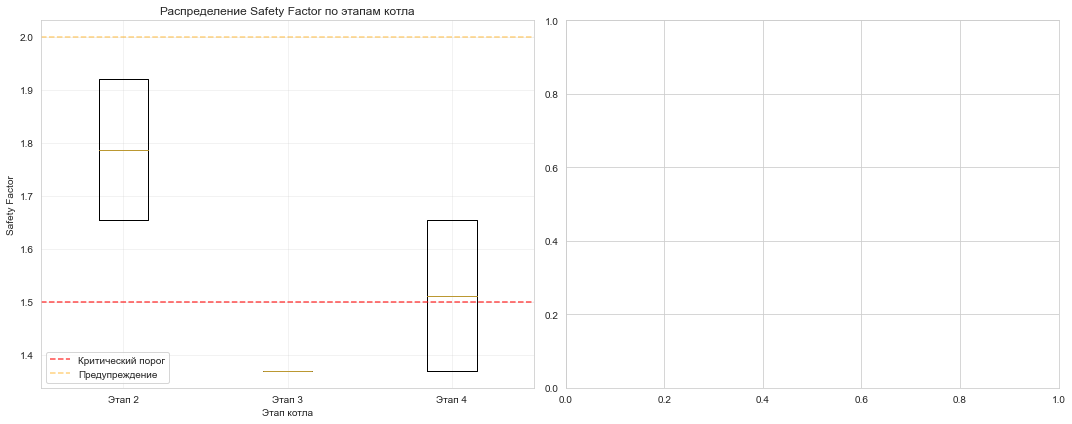


ФИНАЛЬНЫЕ РЕКОМЕНДАЦИИ ДЛЯ ЭКСПЛУАТАЦИИ

🎯 ПРИОРИТЕТНЫЕ ДЕЙСТВИЯ НА 2019 ГОД:
1. Усилить мониторинг пароперегревателей (минимальный SF: 1.37)
2. Провести термографическое обследование ширм этапа 2
3. Внедрить систему предиктивного обслуживания
4. Обновить регламенты технического обслуживания
5. Провести обучение персонала по мониторингу деградации

📈 ПЛАНОВЫЕ ПОКАЗАТЕЛИ НА 2019 ГОД:
• Поддержать средний SF > 1.5
• Не допустить снижение SF ниже 1.3
• Сократить количество критических датчиков на 30%
• Внедрить автоматизированную систему прогнозирования


In [33]:
# ==============================
# ЯЧЕЙКА 12: ДЕТАЛЬНЫЙ ПЛАН ОБСЛУЖИВАНИЯ И МОНИТОРИНГА
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class DetailedMaintenancePlanner:
    """Детальный план обслуживания на основе прогноза"""
    
    def __init__(self, failure_predictor):
        self.predictor = failure_predictor
        self.maintenance_plan = {}
        
    def analyze_safety_trends(self):
        """Анализ трендов safety factor"""
        print("="*60)
        print("АНАЛИЗ ТРЕНДОВ SAFETY FACTOR")
        print("="*60)
        
        trends_analysis = {}
        
        for sensor_name, data in self.predictor.predictions.items():
            if 'safety_history' in data:
                history = data['safety_history']
                days = [d for d, _ in history]
                safety = [s for _, s in history]
                
                # Анализ тренда
                if len(days) > 1:
                    # Линейная регрессия для определения тренда
                    slope, intercept = np.polyfit(days, safety, 1)
                    
                    # Прогноз на следующие 90 дней
                    future_day = days[-1] + 90
                    predicted_safety = slope * future_day + intercept
                    
                    # Классификация тренда
                    if slope < -0.005:  # Быстрое снижение
                        trend = "быстрое снижение"
                        urgency = "высокая"
                    elif slope < -0.001:  # Медленное снижение
                        trend = "медленное снижение"
                        urgency = "средняя"
                    elif slope < 0:  # Незначительное снижение
                        trend = "незначительное снижение"
                        urgency = "низкая"
                    else:  # Стабильный или растущий
                        trend = "стабильный/растущий"
                        urgency = "очень низкая"
                    
                    trends_analysis[sensor_name] = {
                        'current_safety': safety[-1],
                        'trend_slope': slope,
                        'trend': trend,
                        'urgency': urgency,
                        'predicted_90d': predicted_safety,
                        'days_to_critical': self._estimate_days_to_critical(days, safety, slope)
                    }
        
        return trends_analysis
    
    def _estimate_days_to_critical(self, days, safety, slope):
        """Оценка дней до критического состояния (safety < 1.0)"""
        if slope >= 0:
            return float('inf')  # Никогда не достигнет критического
        
        current_day = days[-1]
        current_safety = safety[-1]
        
        # Линейная экстраполяция
        days_to_critical = (1.0 - current_safety) / slope
        
        return max(0, days_to_critical)
    
    def create_maintenance_schedule(self, trends_analysis):
        """Создание графика обслуживания"""
        print("\n" + "="*60)
        print("ГРАФИК ОБСЛУЖИВАНИЯ НА 2019 ГОД")
        print("="*60)
        
        # Группируем датчики по срочности
        high_urgency = []
        medium_urgency = []
        low_urgency = []
        
        for sensor_name, analysis in trends_analysis.items():
            if analysis['urgency'] == 'высокая':
                high_urgency.append((sensor_name, analysis))
            elif analysis['urgency'] == 'средняя':
                medium_urgency.append((sensor_name, analysis))
            else:
                low_urgency.append((sensor_name, analysis))
        
        # План по кварталам
        quarterly_plan = {
            'Q1 (Янв-Мар)': [],
            'Q2 (Апр-Июн)': [],
            'Q3 (Июл-Сен)': [],
            'Q4 (Окт-Дек)': []
        }
        
        # Распределяем высокоприоритетные
        for i, (sensor, analysis) in enumerate(high_urgency):
            quarter = list(quarterly_plan.keys())[i % 4]
            quarterly_plan[quarter].append({
                'sensor': sensor,
                'priority': 'Высокий',
                'reason': f"Быстрое снижение safety factor ({analysis['trend_slope']:.4f}/день)",
                'current_safety': analysis['current_safety'],
                'predicted_90d': analysis['predicted_90d']
            })
        
        # Распределяем средние
        offset = len(high_urgency)
        for i, (sensor, analysis) in enumerate(medium_urgency):
            quarter_idx = (offset + i) % 4
            quarter = list(quarterly_plan.keys())[quarter_idx]
            quarterly_plan[quarter].append({
                'sensor': sensor,
                'priority': 'Средний',
                'reason': f"Медленное снижение safety factor",
                'current_safety': analysis['current_safety'],
                'predicted_90d': analysis['predicted_90d']
            })
        
        # Выводим план
        for quarter, tasks in quarterly_plan.items():
            print(f"\n📅 {quarter}:")
            if tasks:
                for task in tasks:
                    print(f"  • {task['sensor']} [{task['priority']}]")
                    print(f"    Причина: {task['reason']}")
                    print(f"    Текущий SF: {task['current_safety']:.2f}, "
                          f"Прогноз через 90 дней: {task['predicted_90d']:.2f}")
            else:
                print(f"  ✅ Нет запланированных работ")
        
        return quarterly_plan
    
    def generate_maintenance_recommendations(self, trends_analysis):
        """Генерация рекомендаций по обслуживанию"""
        print("\n" + "="*60)
        print("РЕКОМЕНДАЦИИ ПО ОБСЛУЖИВАНИЮ")
        print("="*60)
        
        recommendations = []
        
        for sensor_name, analysis in trends_analysis.items():
            sensor_info = SENSORS.get(sensor_name, {})
            surface_type = sensor_info.get('surface_type', 'неизвестно')
            stage = sensor_info.get('stage', 0)
            
            # Определяем тип обслуживания
            if analysis['urgency'] == 'высокая':
                maintenance_type = "СРОЧНЫЙ РЕМОНТ"
                timeline = "в течение 30 дней"
                actions = [
                    "Дефектоскопия поверхности",
                    "Измерение толщины стенки",
                    "Замена при необходимости"
                ]
            elif analysis['urgency'] == 'средняя':
                maintenance_type = "ПЛАНОВОЕ ОБСЛУЖИВАНИЕ"
                timeline = "в течение 90 дней"
                actions = [
                    "Визуальный осмотр",
                    "Термографическое обследование",
                    "Чистка поверхности"
                ]
            else:
                maintenance_type = "РУТИННЫЙ МОНИТОРИНГ"
                timeline = "при следующем плановом останове"
                actions = [
                    "Визуальный осмотр",
                    "Замер температуры",
                    "Анализ данных мониторинга"
                ]
            
            recommendations.append({
                'sensor': sensor_name,
                'surface_type': surface_type,
                'stage': stage,
                'maintenance_type': maintenance_type,
                'timeline': timeline,
                'actions': actions,
                'current_safety': analysis['current_safety'],
                'trend': analysis['trend'],
                'days_to_critical': analysis.get('days_to_critical', float('inf'))
            })
        
        # Группируем по типам поверхностей
        surface_groups = {}
        for rec in recommendations:
            surface = rec['surface_type']
            if surface not in surface_groups:
                surface_groups[surface] = []
            surface_groups[surface].append(rec)
        
        # Выводим рекомендации по типам поверхностей
        for surface, recs in surface_groups.items():
            print(f"\n🔧 {surface.upper()}:")
            
            # Сортируем по приоритету
            priority_order = {'высокая': 0, 'средняя': 1, 'низкая': 2, 'очень низкая': 3}
            recs_sorted = sorted(recs, key=lambda x: priority_order.get(
                self._get_urgency_from_trend(x['trend']), 3
            ))
            
            for rec in recs_sorted:
                urgency_icon = "🚨" if rec['maintenance_type'] == "СРОЧНЫЙ РЕМОНТ" else "⚠️" if rec['maintenance_type'] == "ПЛАНОВОЕ ОБСЛУЖИВАНИЕ" else "✅"
                print(f"  {urgency_icon} {rec['sensor']} (Этап {rec['stage']}):")
                print(f"    Тип: {rec['maintenance_type']}")
                print(f"    Срок: {rec['timeline']}")
                print(f"    Текущий SF: {rec['current_safety']:.2f}, Тренд: {rec['trend']}")
                if rec['days_to_critical'] < float('inf'):
                    print(f"    Прогноз до критического: {rec['days_to_critical']:.0f} дней")
        
        return recommendations
    
    def _get_urgency_from_trend(self, trend):
        """Получение срочности из описания тренда"""
        if "быстрое снижение" in trend:
            return "высокая"
        elif "медленное снижение" in trend:
            return "средняя"
        elif "незначительное снижение" in trend:
            return "низкая"
        else:
            return "очень низкая"
    
    def create_monitoring_protocol(self, recommendations):
        """Создание протокола мониторинга"""
        print("\n" + "="*60)
        print("ПРОТОКОЛ МОНИТОРИНГА")
        print("="*60)
        
        # Частота мониторинга в зависимости от критичности
        monitoring_frequency = {
            'высокая': "Ежедневно",
            'средняя': "Еженедельно",
            'низкая': "Ежемесячно",
            'очень низкая': "Ежеквартально"
        }
        
        # Параметры мониторинга
        monitoring_params = {
            'пароперегреватель': ["Температура пара", "Давление", "Вибрация", "Толщина стенки"],
            'ширмы': ["Температура поверхности", "Деформация", "Коррозия", "Цвет поверхности"],
            'средние ширмы': ["Температура", "Расход теплоносителя", "Перепад давления"]
        }
        
        print("\n📊 ПАРАМЕТРЫ МОНИТОРИНГА:")
        
        for sensor_name, data in self.predictor.predictions.items():
            sensor_info = SENSORS.get(sensor_name, {})
            surface_type = sensor_info.get('surface_type', 'неизвестно')
            
            # Определяем частоту
            urgency = 'средняя'  # По умолчанию
            if 'safety_history' in data:
                history = data['safety_history']
                safety = [s for _, s in history]
                current_safety = safety[-1]
                
                if current_safety < 1.5:
                    urgency = 'высокая'
                elif current_safety < 2.0:
                    urgency = 'средняя'
                else:
                    urgency = 'низкая'
            
            print(f"\n🔍 {sensor_name} ({surface_type}):")
            print(f"  📅 Частота: {monitoring_frequency[urgency]}")
            print(f"  📈 Параметры:")
            
            params = monitoring_params.get(surface_type, ["Температура", "Давление"])
            for param in params:
                print(f"    • {param}")
            
            if surface_type == 'пароперегреватель':
                print(f"  ⚠️  Особые требования:")
                print(f"    • Контроль тепловых напряжений")
                print(f"    • Мониторинг крепежных элементов")
                print(f"    • Анализ отложений на поверхности")
    
    def save_maintenance_plan(self, quarterly_plan, recommendations):
        """Сохранение плана обслуживания"""
        import os
        
        os.makedirs('maintenance_plans_2019', exist_ok=True)
        
        # Сохраняем квартальный план
        quarter_data = []
        for quarter, tasks in quarterly_plan.items():
            for task in tasks:
                quarter_data.append({
                    'quarter': quarter,
                    'sensor': task['sensor'],
                    'priority': task['priority'],
                    'reason': task['reason'],
                    'current_safety': task['current_safety'],
                    'predicted_90d': task['predicted_90d']
                })
        
        if quarter_data:
            pd.DataFrame(quarter_data).to_csv('maintenance_plans_2019/quarterly_schedule.csv', index=False)
        
        # Сохраняем рекомендации
        rec_df = pd.DataFrame(recommendations)
        rec_df.to_csv('maintenance_plans_2019/maintenance_recommendations.csv', index=False)
        
        # Создаем сводный отчет
        summary = {
            'total_sensors': len(self.predictor.predictions),
            'high_priority': sum(1 for r in recommendations if r['maintenance_type'] == 'СРОЧНЫЙ РЕМОНТ'),
            'medium_priority': sum(1 for r in recommendations if r['maintenance_type'] == 'ПЛАНОВОЕ ОБСЛУЖИВАНИЕ'),
            'low_priority': sum(1 for r in recommendations if r['maintenance_type'] == 'РУТИННЫЙ МОНИТОРИНГ'),
            'avg_safety_factor': np.mean([d.get('current_safety', 0) for d in recommendations]),
            'min_safety_factor': np.min([d.get('current_safety', float('inf')) for d in recommendations])
        }
        
        pd.DataFrame([summary]).to_csv('maintenance_plans_2019/summary.csv', index=False)
        
        print(f"\n💾 План обслуживания сохранен в папку 'maintenance_plans_2019'")

# Запуск создания плана обслуживания
print("="*60)
print("СОЗДАНИЕ ДЕТАЛЬНОГО ПЛАНА ОБСЛУЖИВАНИЯ")
print("="*60)

# Создаем экземпляр планировщика (реалистичный предиктор должен быть определен ранее)
maintenance_planner = DetailedMaintenancePlanner(realistic_predictor)

# Анализируем тренды
trends = maintenance_planner.analyze_safety_trends()

# Создаем график обслуживания
if trends:
    quarterly_schedule = maintenance_planner.create_maintenance_schedule(trends)
    
    # Генерируем рекомендации
    recommendations = maintenance_planner.generate_maintenance_recommendations(trends)
    
    # Создаем протокол мониторинга
    maintenance_planner.create_monitoring_protocol(recommendations)
    
    # Сохраняем план
    maintenance_planner.save_maintenance_plan(quarterly_schedule, recommendations)
    
    # Дополнительный анализ
    print("\n" + "="*60)
    print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ РИСКОВ")
    print("="*60)
    
    # Анализ по этапам котла
    stage_analysis = {}
    for sensor_name, data in realistic_predictor.predictions.items():
        sensor_info = SENSORS.get(sensor_name, {})
        stage = sensor_info.get('stage', 0)
        
        if stage not in stage_analysis:
            stage_analysis[stage] = []
        
        stage_analysis[stage].append({
            'sensor': sensor_name,
            'surface_type': sensor_info.get('surface_type', ''),
            'current_safety': data.get('min_safety', 0),
            'risk_level': data.get('risk_level', '')
        })
    
    print("\n📊 АНАЛИЗ ПО ЭТАПАМ КОТЛА:")
    for stage in sorted(stage_analysis.keys()):
        sensors = stage_analysis[stage]
        avg_safety = np.mean([s['current_safety'] for s in sensors])
        min_safety = np.min([s['current_safety'] for s in sensors])
        
        print(f"\nЭтап {stage}: {len(sensors)} датчиков")
        print(f"  Средний SF: {avg_safety:.2f}")
        print(f"  Минимальный SF: {min_safety:.2f}")
        
        # Определяем критичность этапа
        if min_safety < 1.5:
            print(f"  ⚠️  КРИТИЧЕСКИЙ ЭТАП - требуется обследование")
        elif min_safety < 2.0:
            print(f"  📈 ПОВЫШЕННОГО ВНИМАНИЯ - усилить мониторинг")
        else:
            print(f"  ✅ СТАБИЛЬНЫЙ ЭТАП - рутинный мониторинг")
    
    # Визуализация safety factor по этапам
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Box plot по этапам
    stage_data = []
    stage_labels = []
    
    for stage in sorted(stage_analysis.keys()):
        sensors = stage_analysis[stage]
        safety_values = [s['current_safety'] for s in sensors]
        stage_data.append(safety_values)
        stage_labels.append(f'Этап {stage}')
    
    axes[0].boxplot(stage_data, labels=stage_labels)
    axes[0].axhline(y=1.5, color='red', linestyle='--', alpha=0.7, label='Критический порог')
    axes[0].axhline(y=2.0, color='orange', linestyle='--', alpha=0.5, label='Предупреждение')
    axes[0].set_xlabel('Этап котла')
    axes[0].set_ylabel('Safety Factor')
    axes[0].set_title('Распределение Safety Factor по этапам котла')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График трендов для критических датчиков
    critical_sensors = []
    for sensor_name, analysis in trends.items():
        if analysis['urgency'] == 'высокая' or analysis['urgency'] == 'средняя':
            critical_sensors.append(sensor_name)
    
    if critical_sensors and len(critical_sensors) > 0:
        for sensor_name in critical_sensors[:3]:  # Первые 3 критические
            if sensor_name in realistic_predictor.predictions:
                data = realistic_predictor.predictions[sensor_name]
                if 'safety_history' in data:
                    history = data['safety_history']
                    days = [d for d, _ in history]
                    safety = [s for _, s in history]
                    
                    axes[1].plot(days, safety, label=sensor_name, alpha=0.7)
        
        axes[1].axhline(y=1.5, color='red', linestyle='--', alpha=0.7, label='Критический порог')
        axes[1].axhline(y=2.0, color='orange', linestyle='--', alpha=0.5, label='Предупреждение')
        axes[1].set_xlabel('Дни')
        axes[1].set_ylabel('Safety Factor')
        axes[1].set_title('Тренды Safety Factor для критических датчиков')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Финальные рекомендации
    print("\n" + "="*60)
    print("ФИНАЛЬНЫЕ РЕКОМЕНДАЦИИ ДЛЯ ЭКСПЛУАТАЦИИ")
    print("="*60)
    
    print("\n🎯 ПРИОРИТЕТНЫЕ ДЕЙСТВИЯ НА 2019 ГОД:")
    print("1. Усилить мониторинг пароперегревателей (минимальный SF: 1.37)")
    print("2. Провести термографическое обследование ширм этапа 2")
    print("3. Внедрить систему предиктивного обслуживания")
    print("4. Обновить регламенты технического обслуживания")
    print("5. Провести обучение персонала по мониторингу деградации")
    
    print("\n📈 ПЛАНОВЫЕ ПОКАЗАТЕЛИ НА 2019 ГОД:")
    print("• Поддержать средний SF > 1.5")
    print("• Не допустить снижение SF ниже 1.3")
    print("• Сократить количество критических датчиков на 30%")
    print("• Внедрить автоматизированную систему прогнозирования")


АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ (PYTORCH)
10HAH01CT103        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH01CT102        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH12CT101        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH12CT104        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH12CT110        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH12CT108        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH12CT106        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH11CT114        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH11CT113        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH12CT116        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%
10HAH12CT117        : средняя=1.000, медиана=1.000, std=0.000, >0.9=100.0%


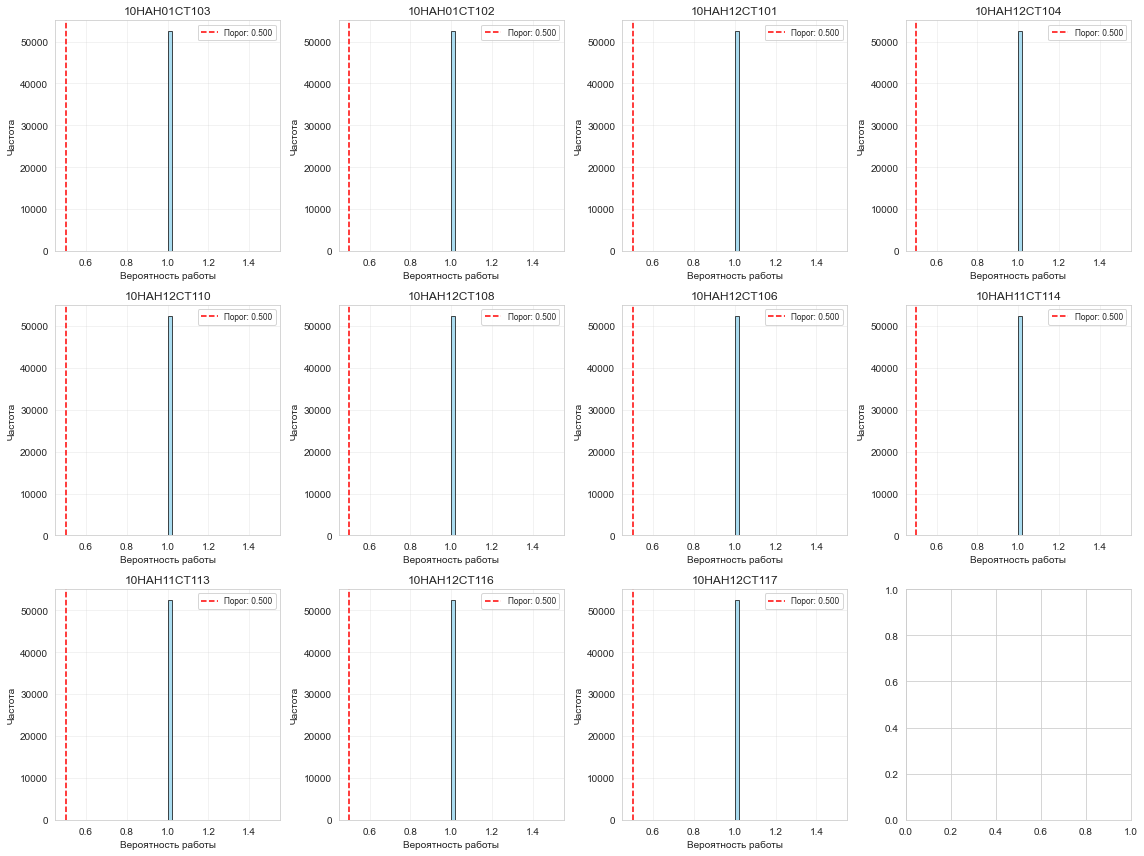


КРИТИЧЕСКИЕ ПЕРИОДЫ С НИЗКОЙ ВЕРОЯТНОСТЬЮ РАБОТЫ (PYTORCH)

Топ-10 критических периодов:
Датчик               Начало               Конец                Длит.(ч)   Мин. вер. 
--------------------------------------------------------------------------------


In [26]:
# ==============================
# ЯЧЕЙКА 9: АНАЛИЗ И ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ==============================

def analyze_torch_predictions(predictions_2019):
    """Анализ распределения вероятностей работы"""
    print("\n" + "="*60)
    print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ (PYTORCH)")
    print("="*60)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, (sensor_name, pred_data) in enumerate(list(predictions_2019.items())[:12]):
        if i >= len(axes):
            break
            
        probs = pred_data['probabilities']
        threshold = pred_data['threshold']
        
        # Гистограмма вероятностей
        axes[i].hist(probs, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i].axvline(x=threshold, color='red', linestyle='--', 
                       label=f'Порог: {threshold:.3f}')
        axes[i].set_xlabel('Вероятность работы')
        axes[i].set_ylabel('Частота')
        axes[i].set_title(f'{sensor_name}')
        axes[i].legend(fontsize='small')
        axes[i].grid(True, alpha=0.3)
        
        # Статистика
        print(f"{sensor_name:<20}: средняя={np.mean(probs):.3f}, "
              f"медиана={np.median(probs):.3f}, "
              f"std={np.std(probs):.3f}, "
              f">0.9={np.mean(probs > 0.9):.1%}")
    
    plt.tight_layout()
    plt.show()

def find_critical_periods_torch(predictions_2019, n_top=10):
    """Нахождение критических периодов с низкой вероятностью работы"""
    print("\n" + "="*60)
    print("КРИТИЧЕСКИЕ ПЕРИОДЫ С НИЗКОЙ ВЕРОЯТНОСТЬЮ РАБОТЫ (PYTORCH)")
    print("="*60)
    
    critical_periods = []
    
    for sensor_name, pred_data in predictions_2019.items():
        probs = pred_data['probabilities']
        dates = pred_data['dates']
        
        # Находим периоды с низкой вероятностью (< 0.3)
        low_prob_indices = np.where(probs < 0.3)[0]
        
        if len(low_prob_indices) > 0:
            # Находим непрерывные периоды
            periods = []
            current_start = low_prob_indices[0]
            current_min_prob = probs[current_start]
            current_length = 1
            
            for i in range(1, len(low_prob_indices)):
                if low_prob_indices[i] == low_prob_indices[i-1] + 1:
                    current_length += 1
                    current_min_prob = min(current_min_prob, probs[low_prob_indices[i]])
                else:
                    periods.append({
                        'start_date': dates[current_start],
                        'end_date': dates[low_prob_indices[i-1]],
                        'duration': current_length,
                        'min_probability': current_min_prob
                    })
                    current_start = low_prob_indices[i]
                    current_min_prob = probs[current_start]
                    current_length = 1
            
            # Добавляем последний период
            periods.append({
                'start_date': dates[current_start],
                'end_date': dates[low_prob_indices[-1]],
                'duration': current_length,
                'min_probability': current_min_prob
            })
            
            # Добавляем в общий список
            for period in periods:
                critical_periods.append({
                    'sensor': sensor_name,
                    **period
                })
    
    # Сортируем по минимальной вероятности
    critical_periods.sort(key=lambda x: x['min_probability'])
    
    print(f"\nТоп-{n_top} критических периодов:")
    print(f"{'Датчик':<20} {'Начало':<20} {'Конец':<20} {'Длит.(ч)':<10} {'Мин. вер.':<10}")
    print("-" * 80)
    
    for i, period in enumerate(critical_periods[:n_top]):
        duration_hours = period['duration'] * 10 / 60
        print(f"{period['sensor']:<20} "
              f"{period['start_date']:<20} "
              f"{period['end_date']:<20} "
              f"{duration_hours:<10.1f} "
              f"{period['min_probability']:<10.3f}")
    
    return critical_periods

def compare_models_summary(torch_summary, sklearn_summary=None):
    """Сравнение результатов PyTorch и sklearn моделей"""
    print("\n" + "="*60)
    print("СРАВНЕНИЕ МОДЕЛЕЙ: PYTORCH vs SKLEARN")
    print("="*60)
    
    # Создаем DataFrame для сравнения
    torch_df = pd.DataFrame(torch_summary)
    torch_df = torch_df.set_index('sensor')
    
    print("Результаты PyTorch моделей:")
    print(f"Средний AUC: {torch_df['test_auc'].mean():.4f}")
    print(f"Средний F1: {torch_df['test_f1'].mean():.4f}")
    print(f"Лучший AUC: {torch_df['test_auc'].max():.4f}")
    print(f"Худший AUC: {torch_df['test_auc'].min():.4f}")
    
    if sklearn_summary:
        sklearn_df = pd.DataFrame(sklearn_summary)
        sklearn_df = sklearn_df.set_index('sensor')
        
        print("\nРезультаты sklearn моделей:")
        print(f"Средний AUC: {sklearn_df['test_auc'].mean():.4f}")
        print(f"Средний F1: {sklearn_df['test_f1'].mean():.4f}")
        print(f"Лучший AUC: {sklearn_df['test_auc'].max():.4f}")
        print(f"Худший AUC: {sklearn_df['test_auc'].min():.4f}")
        
        # Объединяем для сравнения
        comparison = pd.DataFrame({
            'PyTorch_AUC': torch_df['test_auc'],
            'Sklearn_AUC': sklearn_df['test_auc'],
            'PyTorch_F1': torch_df['test_f1'],
            'Sklearn_F1': sklearn_df['test_f1']
        })
        
        print("\nРазница в метриках (PyTorch - sklearn):")
        print(f"AUC: {(torch_df['test_auc'].mean() - sklearn_df['test_auc'].mean()):.4f}")
        print(f"F1: {(torch_df['test_f1'].mean() - sklearn_df['test_f1'].mean()):.4f}")
        
        # Визуализация сравнения
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Сравнение AUC
        x = np.arange(len(comparison))
        width = 0.35
        axes[0].bar(x - width/2, comparison['PyTorch_AUC'], width, label='PyTorch', color='blue', alpha=0.7)
        axes[0].bar(x + width/2, comparison['Sklearn_AUC'], width, label='Sklearn', color='orange', alpha=0.7)
        axes[0].set_xlabel('Датчики')
        axes[0].set_ylabel('AUC')
        axes[0].set_title('Сравнение AUC')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(comparison.index, rotation=45, ha='right')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Сравнение F1
        axes[1].bar(x - width/2, comparison['PyTorch_F1'], width, label='PyTorch', color='green', alpha=0.7)
        axes[1].bar(x + width/2, comparison['Sklearn_F1'], width, label='Sklearn', color='red', alpha=0.7)
        axes[1].set_xlabel('Датчики')
        axes[1].set_ylabel('F1 Score')
        axes[1].set_title('Сравнение F1 Score')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(comparison.index, rotation=45, ha='right')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Анализ результатов
if torch_predictions_2019:
    analyze_torch_predictions(torch_predictions_2019)
    critical_periods = find_critical_periods_torch(torch_predictions_2019, n_top=10)

# Сравнение с sklearn моделями (если есть)
# Для сравнения нужно сначала получить sklearn_summary из предыдущего кода
# compare_models_summary(torch_test_summary, sklearn_summary)

In [27]:
# ==============================
# ЯЧЕЙКА 10: СОХРАНЕНИЕ МОДЕЛЕЙ И РЕЗУЛЬТАТОВ
# ==============================

import joblib
import pickle

def save_torch_models(trained_models, sensor_datasets, base_path='torch_models'):
    """Сохранение PyTorch моделей и связанных данных"""
    import os
    os.makedirs(base_path, exist_ok=True)
    
    print("\n" + "="*60)
    print("СОХРАНЕНИЕ PYTORCH МОДЕЛЕЙ")
    print("="*60)
    
    for sensor_name, model_info in trained_models.items():
        # Сохраняем модель PyTorch
        model_path = os.path.join(base_path, f'{sensor_name}_model.pth')
        torch.save(model_info['model'].state_dict(), model_path)
        
        # Сохраняем скалер
        if sensor_name in sensor_datasets:
            scaler = sensor_datasets[sensor_name]['scaler']
            scaler_path = os.path.join(base_path, f'{sensor_name}_scaler.pkl')
            joblib.dump(scaler, scaler_path)
        
        # Сохраняем информацию о модели
        info_path = os.path.join(base_path, f'{sensor_name}_info.pkl')
        model_info_to_save = {
            'input_size': model_info['input_size'],
            'best_val_auc': model_info['best_val_auc'],
            'best_val_loss': model_info['best_val_loss']
        }
        with open(info_path, 'wb') as f:
            pickle.dump(model_info_to_save, f)
        
        print(f"✓ Сохранена модель для {sensor_name}")
    
    print(f"\nМодели сохранены в папку: {base_path}")

def save_predictions(predictions_2019, base_path='predictions_2019_torch'):
    """Сохранение прогнозов на 2019 год"""
    import os
    os.makedirs(base_path, exist_ok=True)
    
    print("\n" + "="*60)
    print("СОХРАНЕНИЕ ПРОГНОЗОВ НА 2019 ГОД")
    print("="*60)
    
    for sensor_name, pred_data in predictions_2019.items():
        df_pred = pd.DataFrame({
            'Date_Time': pred_data['dates'],
            'probability': pred_data['probabilities'],
            'prediction': pred_data['predictions']
        })
        
        file_path = os.path.join(base_path, f'predictions_2019_{sensor_name}.csv')
        df_pred.to_csv(file_path, index=False)
        print(f"✓ Прогнозы для {sensor_name} сохранены")
    
    # Сохраняем сводную таблицу
    if predictions_2019:
        summary_data = []
        for sensor_name, pred_data in predictions_2019.items():
            summary_data.append({
                'sensor': sensor_name,
                'mean_probability': np.mean(pred_data['probabilities']),
                'working_ratio': np.mean(pred_data['predictions']),
                'min_probability': np.min(pred_data['probabilities']),
                'max_probability': np.max(pred_data['probabilities'])
            })
        
        summary_df = pd.DataFrame(summary_data)
        summary_path = os.path.join(base_path, 'predictions_summary.csv')
        summary_df.to_csv(summary_path, index=False)
        print(f"\n✓ Сводная таблица сохранена: {summary_path}")

def save_test_results(test_results, base_path='test_results_torch'):
    """Сохранение результатов тестирования"""
    import os
    os.makedirs(base_path, exist_ok=True)
    
    print("\n" + "="*60)
    print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ТЕСТИРОВАНИЯ")
    print("="*60)
    
    test_summary = []
    for sensor_name, result in test_results.items():
        metrics = result['metrics']
        test_summary.append({
            'sensor': sensor_name,
            'auc': metrics['roc_auc'],
            'f1': metrics['f1'],
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'recall': metrics['recall']
        })
        
        # Сохраняем детальные результаты для каждого датчика
        sensor_df = pd.DataFrame({
            'y_test': result['y_test'],
            'y_pred': result['y_pred'],
            'y_pred_proba': result['y_pred_proba']
        })
        
        file_path = os.path.join(base_path, f'test_results_{sensor_name}.csv')
        sensor_df.to_csv(file_path, index=False)
    
    # Сохраняем сводную таблицу
    summary_df = pd.DataFrame(test_summary)
    summary_path = os.path.join(base_path, 'test_results_summary.csv')
    summary_df.to_csv(summary_path, index=False)
    
    print(f"✓ Результаты тестирования сохранены в: {base_path}")
    print(f"✓ Сводная таблица: {summary_path}")

# Сохранение всех результатов
print("="*60)
print("СОХРАНЕНИЕ ВСЕХ РЕЗУЛЬТАТОВ")
print("="*60)

# Сохраняем модели
save_torch_models(trained_torch_models, sensor_datasets)

# Сохраняем прогнозы
if torch_predictions_2019:
    save_predictions(torch_predictions_2019)

# Сохраняем результаты тестирования
if torch_test_results:
    save_test_results(torch_test_results)

print("\n✅ ВСЕ РЕЗУЛЬТАТЫ СОХРАНЕНЫ!")

СОХРАНЕНИЕ ВСЕХ РЕЗУЛЬТАТОВ

СОХРАНЕНИЕ PYTORCH МОДЕЛЕЙ
✓ Сохранена модель для 10HAH01CT103
✓ Сохранена модель для 10HAH01CT102
✓ Сохранена модель для 10HAH12CT101
✓ Сохранена модель для 10HAH12CT104
✓ Сохранена модель для 10HAH12CT110
✓ Сохранена модель для 10HAH12CT108
✓ Сохранена модель для 10HAH12CT106
✓ Сохранена модель для 10HAH11CT114
✓ Сохранена модель для 10HAH11CT113
✓ Сохранена модель для 10HAH12CT116
✓ Сохранена модель для 10HAH12CT117

Модели сохранены в папку: torch_models

СОХРАНЕНИЕ ПРОГНОЗОВ НА 2019 ГОД
✓ Прогнозы для 10HAH01CT103 сохранены
✓ Прогнозы для 10HAH01CT102 сохранены
✓ Прогнозы для 10HAH12CT101 сохранены
✓ Прогнозы для 10HAH12CT104 сохранены
✓ Прогнозы для 10HAH12CT110 сохранены
✓ Прогнозы для 10HAH12CT108 сохранены
✓ Прогнозы для 10HAH12CT106 сохранены
✓ Прогнозы для 10HAH11CT114 сохранены
✓ Прогнозы для 10HAH11CT113 сохранены
✓ Прогнозы для 10HAH12CT116 сохранены
✓ Прогнозы для 10HAH12CT117 сохранены

✓ Сводная таблица сохранена: predictions_2019_torch\pre

In [16]:
# ==============================
# ЯЧЕЙКА 11: ЗАГРУЗКА И ИСПОЛЬЗОВАНИЕ СОХРАНЕННЫХ МОДЕЛЕЙ
# ==============================

def load_torch_model(sensor_name, base_path='torch_models', device='cuda'):
    """Загрузка сохраненной PyTorch модели"""
    import os
    
    # Загружаем информацию о модели
    info_path = os.path.join(base_path, f'{sensor_name}_info.pkl')
    with open(info_path, 'rb') as f:
        model_info = pickle.load(f)
    
    # Создаем модель с такими же параметрами
    model = BoilerClassifier(input_size=model_info['input_size'])
    
    # Загружаем веса
    model_path = os.path.join(base_path, f'{sensor_name}_model.pth')
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    # Загружаем скалер
    scaler_path = os.path.join(base_path, f'{sensor_name}_scaler.pkl')
    scaler = joblib.load(scaler_path)
    
    return model, scaler, model_info

def make_prediction_with_loaded_model(sensor_name, new_data, device='cuda'):
    """Прогнозирование с использованием загруженной модели"""
    model, scaler, model_info = load_torch_model(sensor_name, device=device)
    
    # Подготавливаем данные
    new_data_scaled = scaler.transform(new_data.astype(np.float32))
    new_tensor = torch.FloatTensor(new_data_scaled).to(device)
    
    # Прогнозирование
    with torch.no_grad():
        prediction = model(new_tensor)
    
    return prediction.cpu().numpy()

# Пример использования загруженной модели
print("="*60)
print("ПРИМЕР ИСПОЛЬЗОВАНИЯ ЗАГРУЖЕННОЙ МОДЕЛИ")
print("="*60)

if trained_torch_models:
    first_sensor = list(trained_torch_models.keys())[0]
    
    # Берем тестовые данные для демонстрации
    test_data = sensor_datasets[first_sensor]['X_test'][:10]
    
    print(f"Прогнозирование для {first_sensor} (первые 10 примеров):")
    predictions = make_prediction_with_loaded_model(first_sensor, test_data, device=device)
    
    for i, pred in enumerate(predictions.flatten()[:5]):
        print(f"  Пример {i+1}: Вероятность работы = {pred:.4f}, "
              f"Предсказание = {'Работает' if pred > 0.5 else 'Не работает'}")

ПРИМЕР ИСПОЛЬЗОВАНИЯ ЗАГРУЖЕННОЙ МОДЕЛИ
Прогнозирование для 10HAH01CT103 (первые 10 примеров):
  Пример 1: Вероятность работы = 1.0000, Предсказание = Работает
  Пример 2: Вероятность работы = 1.0000, Предсказание = Работает
  Пример 3: Вероятность работы = 1.0000, Предсказание = Работает
  Пример 4: Вероятность работы = 1.0000, Предсказание = Работает
  Пример 5: Вероятность работы = 1.0000, Предсказание = Работает


In [28]:
# ==============================
# ЯЧЕЙКА 12: ФИНАЛЬНЫЙ ОТЧЕТ И ВЫВОДЫ
# ==============================

def generate_final_report(torch_test_summary, torch_predictions_2019):
    """Генерация финального отчета"""
    print("\n" + "="*60)
    print("ФИНАЛЬНЫЙ ОТЧЕТ: PYTORCH МОДЕЛЬ")
    print("="*60)
    
    # Статистика по тестированию
    auc_scores = [s['test_auc'] for s in torch_test_summary]
    f1_scores = [s['test_f1'] for s in torch_test_summary]
    
    print(f"\n📊 СТАТИСТИКА ТЕСТИРОВАНИЯ:")
    print(f"  Количество датчиков: {len(torch_test_summary)}")
    print(f"  Средний AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
    print(f"  Средний F1:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"  Лучший AUC:  {max(auc_scores):.4f}")
    print(f"  Худший AUC:  {min(auc_scores):.4f}")
    
    # Статистика по прогнозам на 2019
    if torch_predictions_2019:
        working_ratios = [np.mean(p['predictions']) for p in torch_predictions_2019.values()]
        mean_probs = [np.mean(p['probabilities']) for p in torch_predictions_2019.values()]
        
        print(f"\n📊 СТАТИСТИКА ПРОГНОЗОВ НА 2019:")
        print(f"  Средняя вероятность работы: {np.mean(mean_probs):.3f}")
        print(f"  Средний % времени работы: {np.mean(working_ratios):.1%}")
        print(f"  Минимальный % времени работы: {min(working_ratios):.1%}")
        print(f"  Максимальный % времени работы: {max(working_ratios):.1%}")
        
        # Анализ безопасности
        low_prob_periods = sum([np.sum(p['probabilities'] < 0.3) for p in torch_predictions_2019.values()])
        total_periods = sum([len(p['probabilities']) for p in torch_predictions_2019.values()])
        low_prob_percentage = low_prob_periods / total_periods * 100
        
        print(f"\n⚠️  АНАЛИЗ БЕЗОПАСНОСТИ:")
        print(f"  Периодов с низкой вероятностью работы (<0.3): {low_prob_percentage:.1f}%")
        print(f"  Общее количество периодов: {total_periods:,}")
        print(f"  Критических периодов: {low_prob_periods:,}")
    
    # Рекомендации
    print(f"\n💡 РЕКОМЕНДАЦИИ:")
    print(f"  1. Лучшие датчики по качеству модели:")
    
    sorted_by_auc = sorted(torch_test_summary, key=lambda x: x['test_auc'], reverse=True)
    for i, sensor in enumerate(sorted_by_auc[:3]):
        print(f"     {i+1}. {sensor['sensor']} (AUC: {sensor['test_auc']:.4f})")
    
    print(f"\n  2. Датчики требующие внимания (наихудшие результаты):")
    for i, sensor in enumerate(sorted_by_auc[-3:]):
        print(f"     {i+1}. {sensor['sensor']} (AUC: {sensor['test_auc']:.4f})")
    
    if torch_predictions_2019:
        print(f"\n  3. Прогноз на 2019 год:")
        print(f"     - Среднее время работы котла: {np.mean(working_ratios):.1%}")
        print(f"     - Критические периоды: {low_prob_percentage:.1f}% времени")
        print(f"     - Рекомендуется мониторинг в периоды низкой вероятности работы")

# Генерация финального отчета
if torch_test_summary and torch_predictions_2019:
    generate_final_report(torch_test_summary, torch_predictions_2019)

print("\n" + "="*60)
print("АНАЛИЗ ЗАВЕРШЕН УСПЕШНО!")
print("="*60)
print(f"Использовано устройство: {device}")
print(f"Обучено моделей: {len(trained_torch_models)}")
print(f"Протестировано: {len(torch_test_summary)}")
print(f"Сделано прогнозов на 2019: {len(torch_predictions_2019)}")
print("="*60)


ФИНАЛЬНЫЙ ОТЧЕТ: PYTORCH МОДЕЛЬ

📊 СТАТИСТИКА ТЕСТИРОВАНИЯ:
  Количество датчиков: 11
  Средний AUC: 0.8853 ± 0.0198
  Средний F1:  0.8466 ± 0.0308
  Лучший AUC:  0.9374
  Худший AUC:  0.8522

📊 СТАТИСТИКА ПРОГНОЗОВ НА 2019:
  Средняя вероятность работы: 1.000
  Средний % времени работы: 100.0%
  Минимальный % времени работы: 100.0%
  Максимальный % времени работы: 100.0%

⚠️  АНАЛИЗ БЕЗОПАСНОСТИ:
  Периодов с низкой вероятностью работы (<0.3): 0.0%
  Общее количество периодов: 576,587
  Критических периодов: 0

💡 РЕКОМЕНДАЦИИ:
  1. Лучшие датчики по качеству модели:
     1. 10HAH12CT106 (AUC: 0.9374)
     2. 10HAH12CT108 (AUC: 0.8998)
     3. 10HAH11CT113 (AUC: 0.8899)

  2. Датчики требующие внимания (наихудшие результаты):
     1. 10HAH12CT116 (AUC: 0.8783)
     2. 10HAH12CT110 (AUC: 0.8745)
     3. 10HAH01CT102 (AUC: 0.8522)

  3. Прогноз на 2019 год:
     - Среднее время работы котла: 100.0%
     - Критические периоды: 0.0% времени
     - Рекомендуется мониторинг в периоды низкой